Part 1: Data Understanding, Exploratory Data Analysis (EDA), 
Data Quality Assessment and Data Preprocessing (30 Marks) 

First, load the library

In [1]:
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import Perceptron

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    multilabel_confusion_matrix,
    ConfusionMatrixDisplay,
    mean_absolute_error, 
    root_mean_squared_error, 
    r2_score
)

from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

from sklearn.feature_selection import f_classif

import tensorflow as tf
import tensorflow.keras.backend as K


Read the dataset

In [2]:
# Read the dataset
df = pd.read_csv("NZ_LUCAS_SMAP_NIWA.csv")

inspect the dataset using descriptive analysis

In [3]:
# Display first 5 rows
print(df.head())

# Check dataset shape
print("Shape:", df.shape)

# Check column names
print("Columns:", df.columns)

# Check for missing values
print(df.isnull().sum())

    latitude   longitude  elevation_m  slope_deg  aspect_deg  \
0 -42.130978  171.117262    97.315825  15.660394  335.473600   
1 -34.640714  172.154664   148.801024   7.974421   38.849851   
2 -37.484079  177.109116   888.809683   9.953119  200.974535   
3 -39.217440  170.420057   394.131619   6.907954   34.959548   
4 -44.971758  177.305446   719.187523   4.219457  205.925811   

   topographic_wetness_index  terrain_ruggedness_index  annual_rainfall_mm  \
0                   7.508100                  7.365608          807.582011   
1                   7.326739                  5.683267         1179.458440   
2                  11.180950                  2.654730          943.442971   
3                   5.846627                  4.005192         1155.294725   
4                   7.425487                  9.832291         1286.631423   

   annual_temperature_c  summer_temperature_c  ...  cation_exchange_capacity  \
0              9.679469             17.235948  ...                

The dataset has 5000 rows and 37 columns. We can see that there is a column named "36" probably a typo so I will ignore this column

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 37 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   latitude                         5000 non-null   float64
 1   longitude                        5000 non-null   float64
 2   elevation_m                      5000 non-null   float64
 3   slope_deg                        5000 non-null   float64
 4   aspect_deg                       5000 non-null   float64
 5   topographic_wetness_index        5000 non-null   float64
 6   terrain_ruggedness_index         5000 non-null   float64
 7   annual_rainfall_mm               5000 non-null   float64
 8   annual_temperature_c             5000 non-null   float64
 9   summer_temperature_c             5000 non-null   float64
 10  winter_temperature_c             5000 non-null   float64
 11  solar_radiation_mj               5000 non-null   float64
 12  potential_evapotranspiration_mm

So all the attributes are float or interger

We look at some discriptive analysis of the attributes 

In [5]:
df.describe()

,latitude,longitude,elevation_m,slope_deg,aspect_deg,topographic_wetness_index,terrain_ruggedness_index,annual_rainfall_mm,annual_temperature_c,summer_temperature_c,...,cation_exchange_capacity,ndvi_mean,evi_mean,ndwi_mean,soil_moisture_pct,soil_quality_index,climate_stress_index,erosion_risk_index,soil_organic_carbon_target,36
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,...,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,0.0
mean,-40.541184,172.389333,504.696286,11.995591,178.768030,7.988307,5.008502,1208.560445,11.978216,18.007048,...,17.980862,0.618753,0.496562,0.248782,32.113719,71.017943,20.755863,30.040320,63.027099,NaN
std,3.765237,3.713015,354.602398,8.321450,103.668752,2.005968,1.979305,392.354324,2.964821,3.128551,...,5.997975,0.118695,0.107143,0.145561,9.789973,9.177922,10.982710,16.380964,9.645272,NaN
min,-46.999849,166.000687,3.386511,0.033139,0.001993,-0.372295,-1.393806,400.000000,4.000000,7.425280,...,3.000000,0.166220,0.106668,-0.239785,5.000000,38.841685,0.000000,0.000000,30.289095,NaN
25%,-43.829784,169.212897,245.034151,5.740084,88.885504,6.620432,3.630864,927.915620,9.928302,15.903511,...,13.816697,0.538136,0.422380,0.151661,25.439275,64.815829,12.695840,18.501431,56.410138,NaN
50%,-40.499888,172.317630,423.162023,10.117302,179.714007,7.959823,4.986927,1206.284688,11.959494,18.018449,...,17.901570,0.619458,0.496783,0.248332,31.898949,70.861879,20.021261,28.710494,62.974905,NaN
75%,-37.274689,175.533831,679.063317,16.223400,268.169344,9.330974,6.375344,1478.904594,13.985086,20.048785,...,22.209178,0.698464,0.569793,0.343520,38.597556,77.252864,28.520322,40.073747,69.386694,NaN
max,-34.003670,178.993568,2418.439425,45.000000,359.924174,16.597715,11.674764,2588.146732,20.000000,27.897761,...,39.411933,0.950000,0.862023,0.800000,67.233048,100.000000,65.018641,100.000000,101.456979,NaN


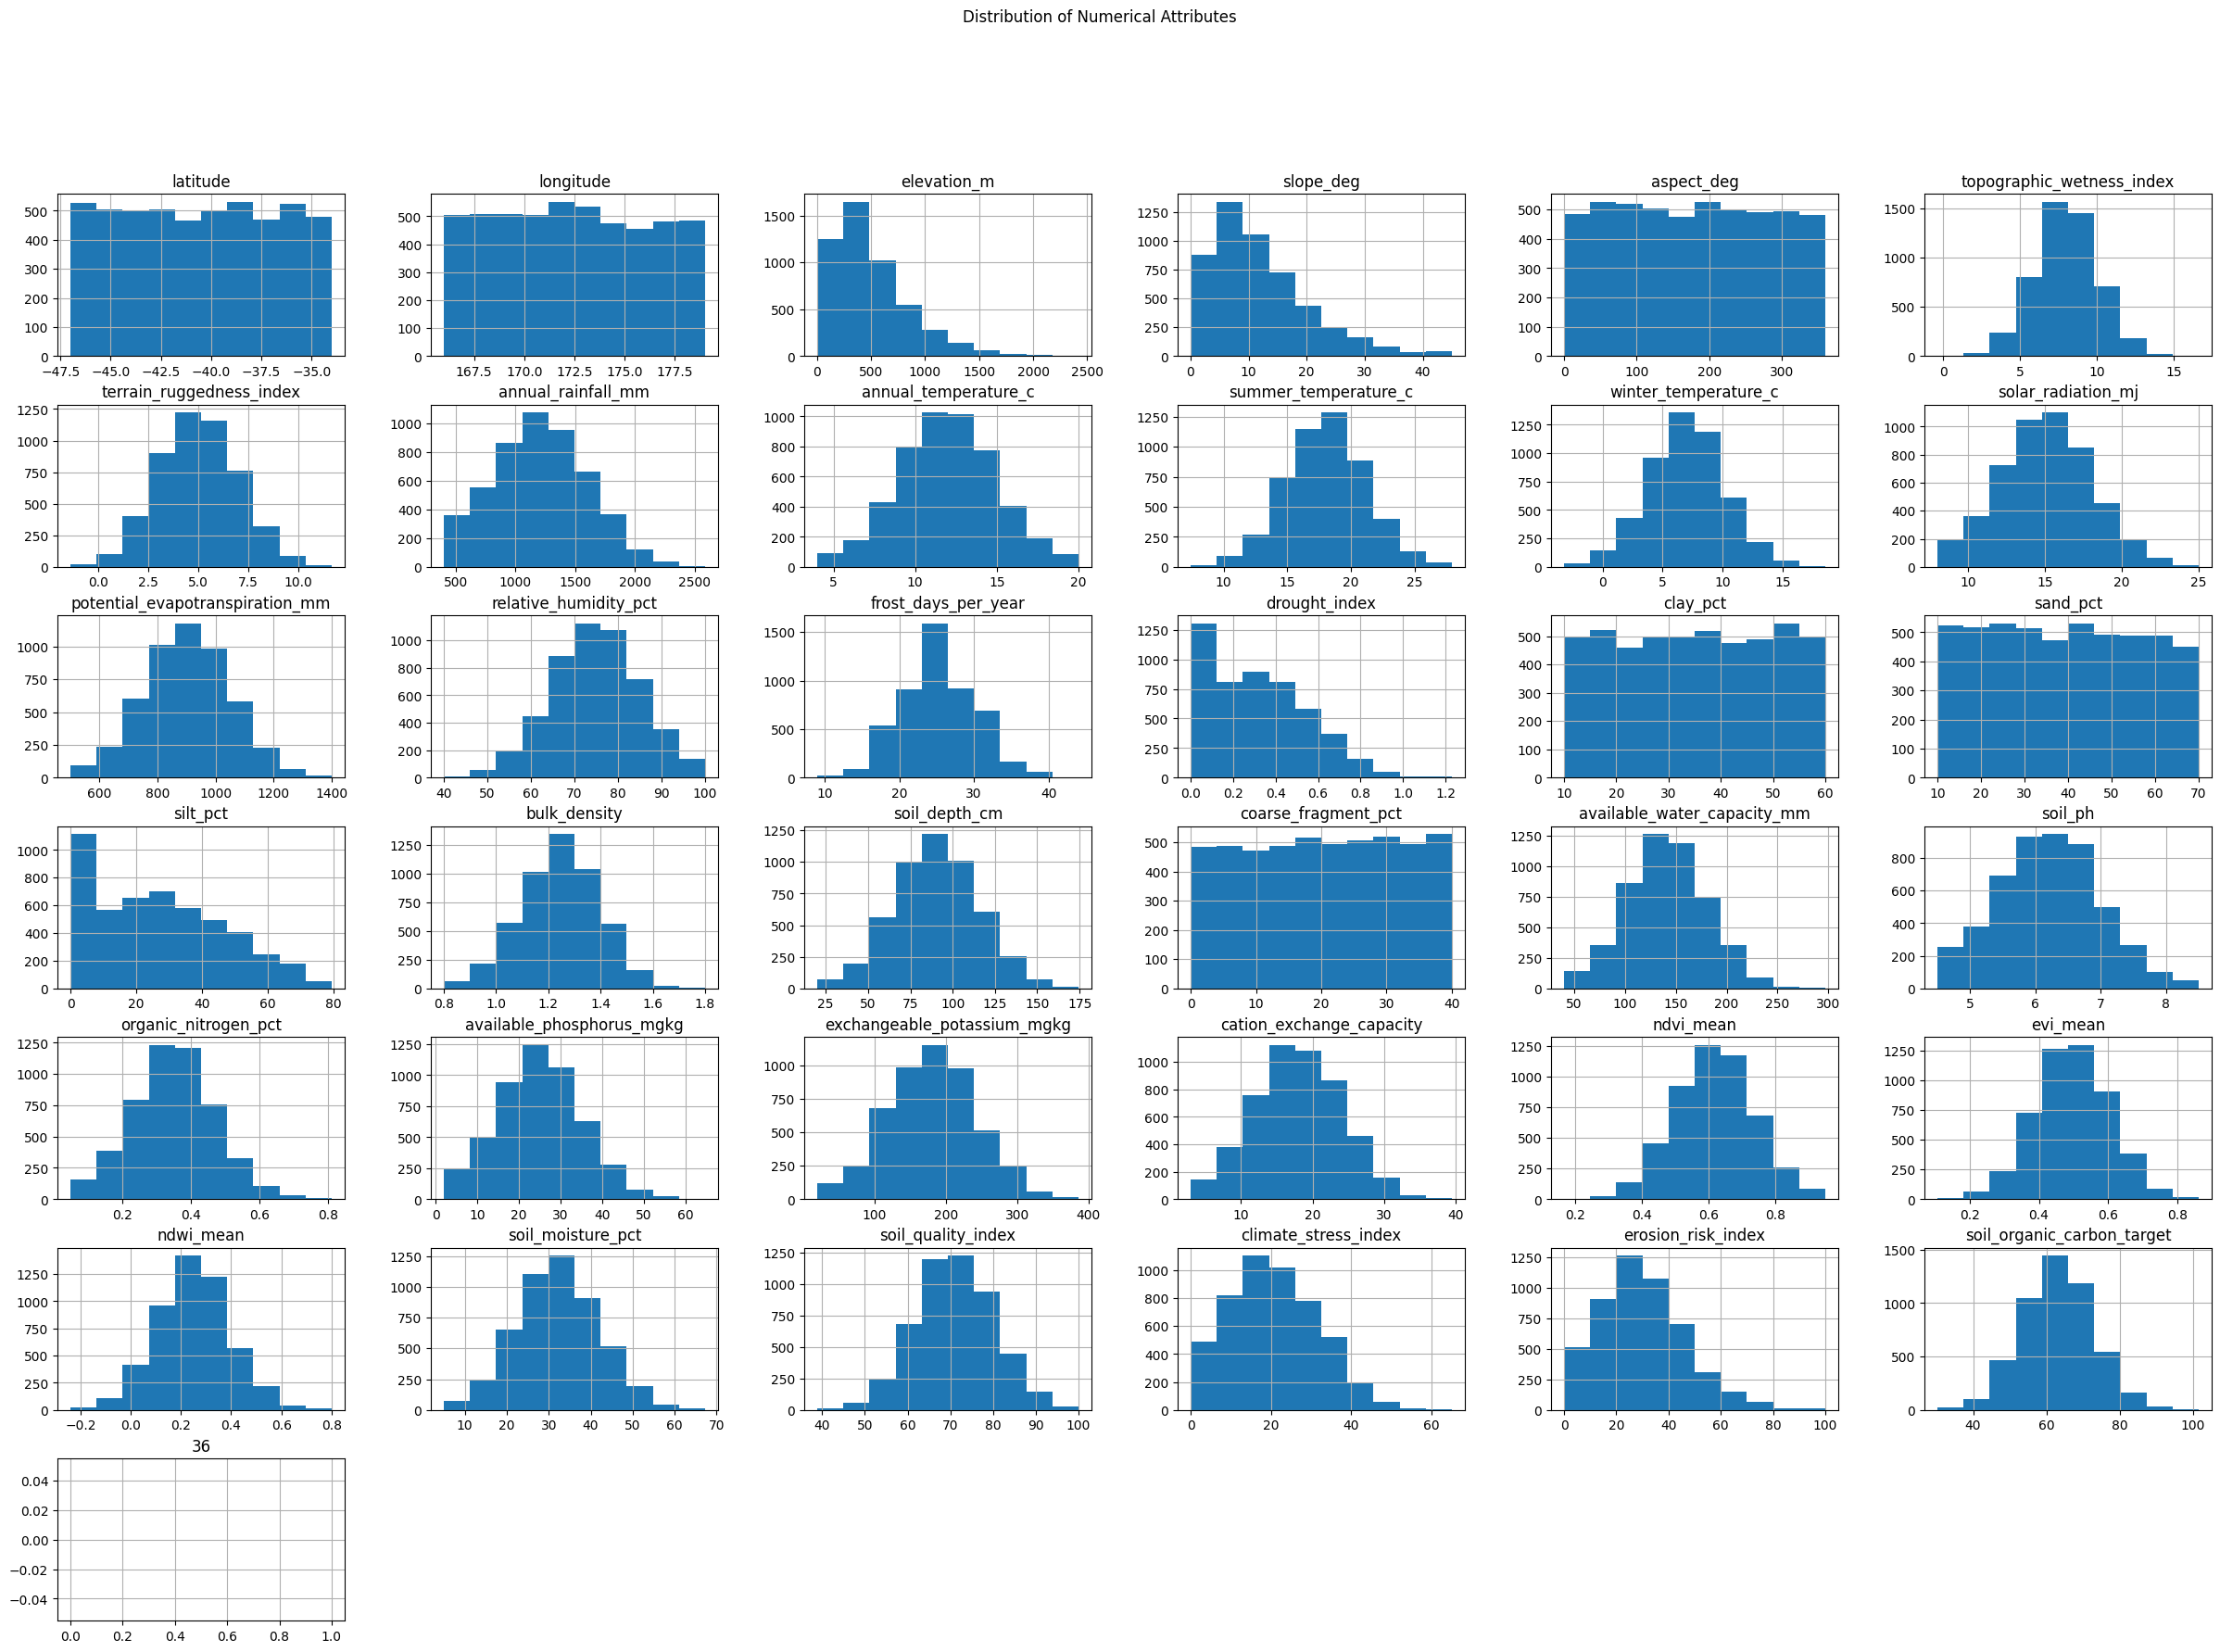

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
df.hist(figsize=(30,20), bins=10)

plt.suptitle("Distribution of Numerical Attributes")
plt.show()

Visualise the outlier

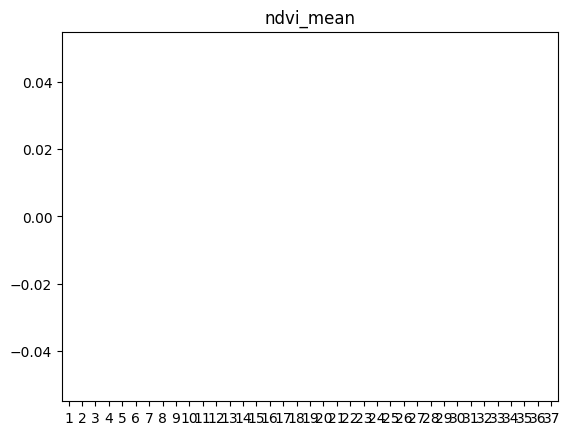

In [7]:
import matplotlib.pyplot as plt

plt.boxplot(df.dropna())
plt.title("ndvi_mean")
plt.show()

                                 latitude  longitude  elevation_m  slope_deg  \
latitude                         1.000000  -0.007017     0.009618  -0.012696   
longitude                       -0.007017   1.000000    -0.000917  -0.006875   
elevation_m                      0.009618  -0.000917     1.000000   0.003947   
slope_deg                       -0.012696  -0.006875     0.003947   1.000000   
aspect_deg                       0.009606   0.027185    -0.018742  -0.016304   
topographic_wetness_index        0.035214  -0.004480    -0.014719   0.004422   
terrain_ruggedness_index         0.010399   0.009148    -0.027970  -0.021542   
annual_rainfall_mm              -0.006504   0.012395    -0.024788  -0.012274   
annual_temperature_c             0.001136  -0.032947    -0.007204  -0.014971   
summer_temperature_c            -0.000262  -0.026475    -0.001676  -0.019784   
winter_temperature_c            -0.003122  -0.026414    -0.006132  -0.007631   
solar_radiation_mj              -0.00842

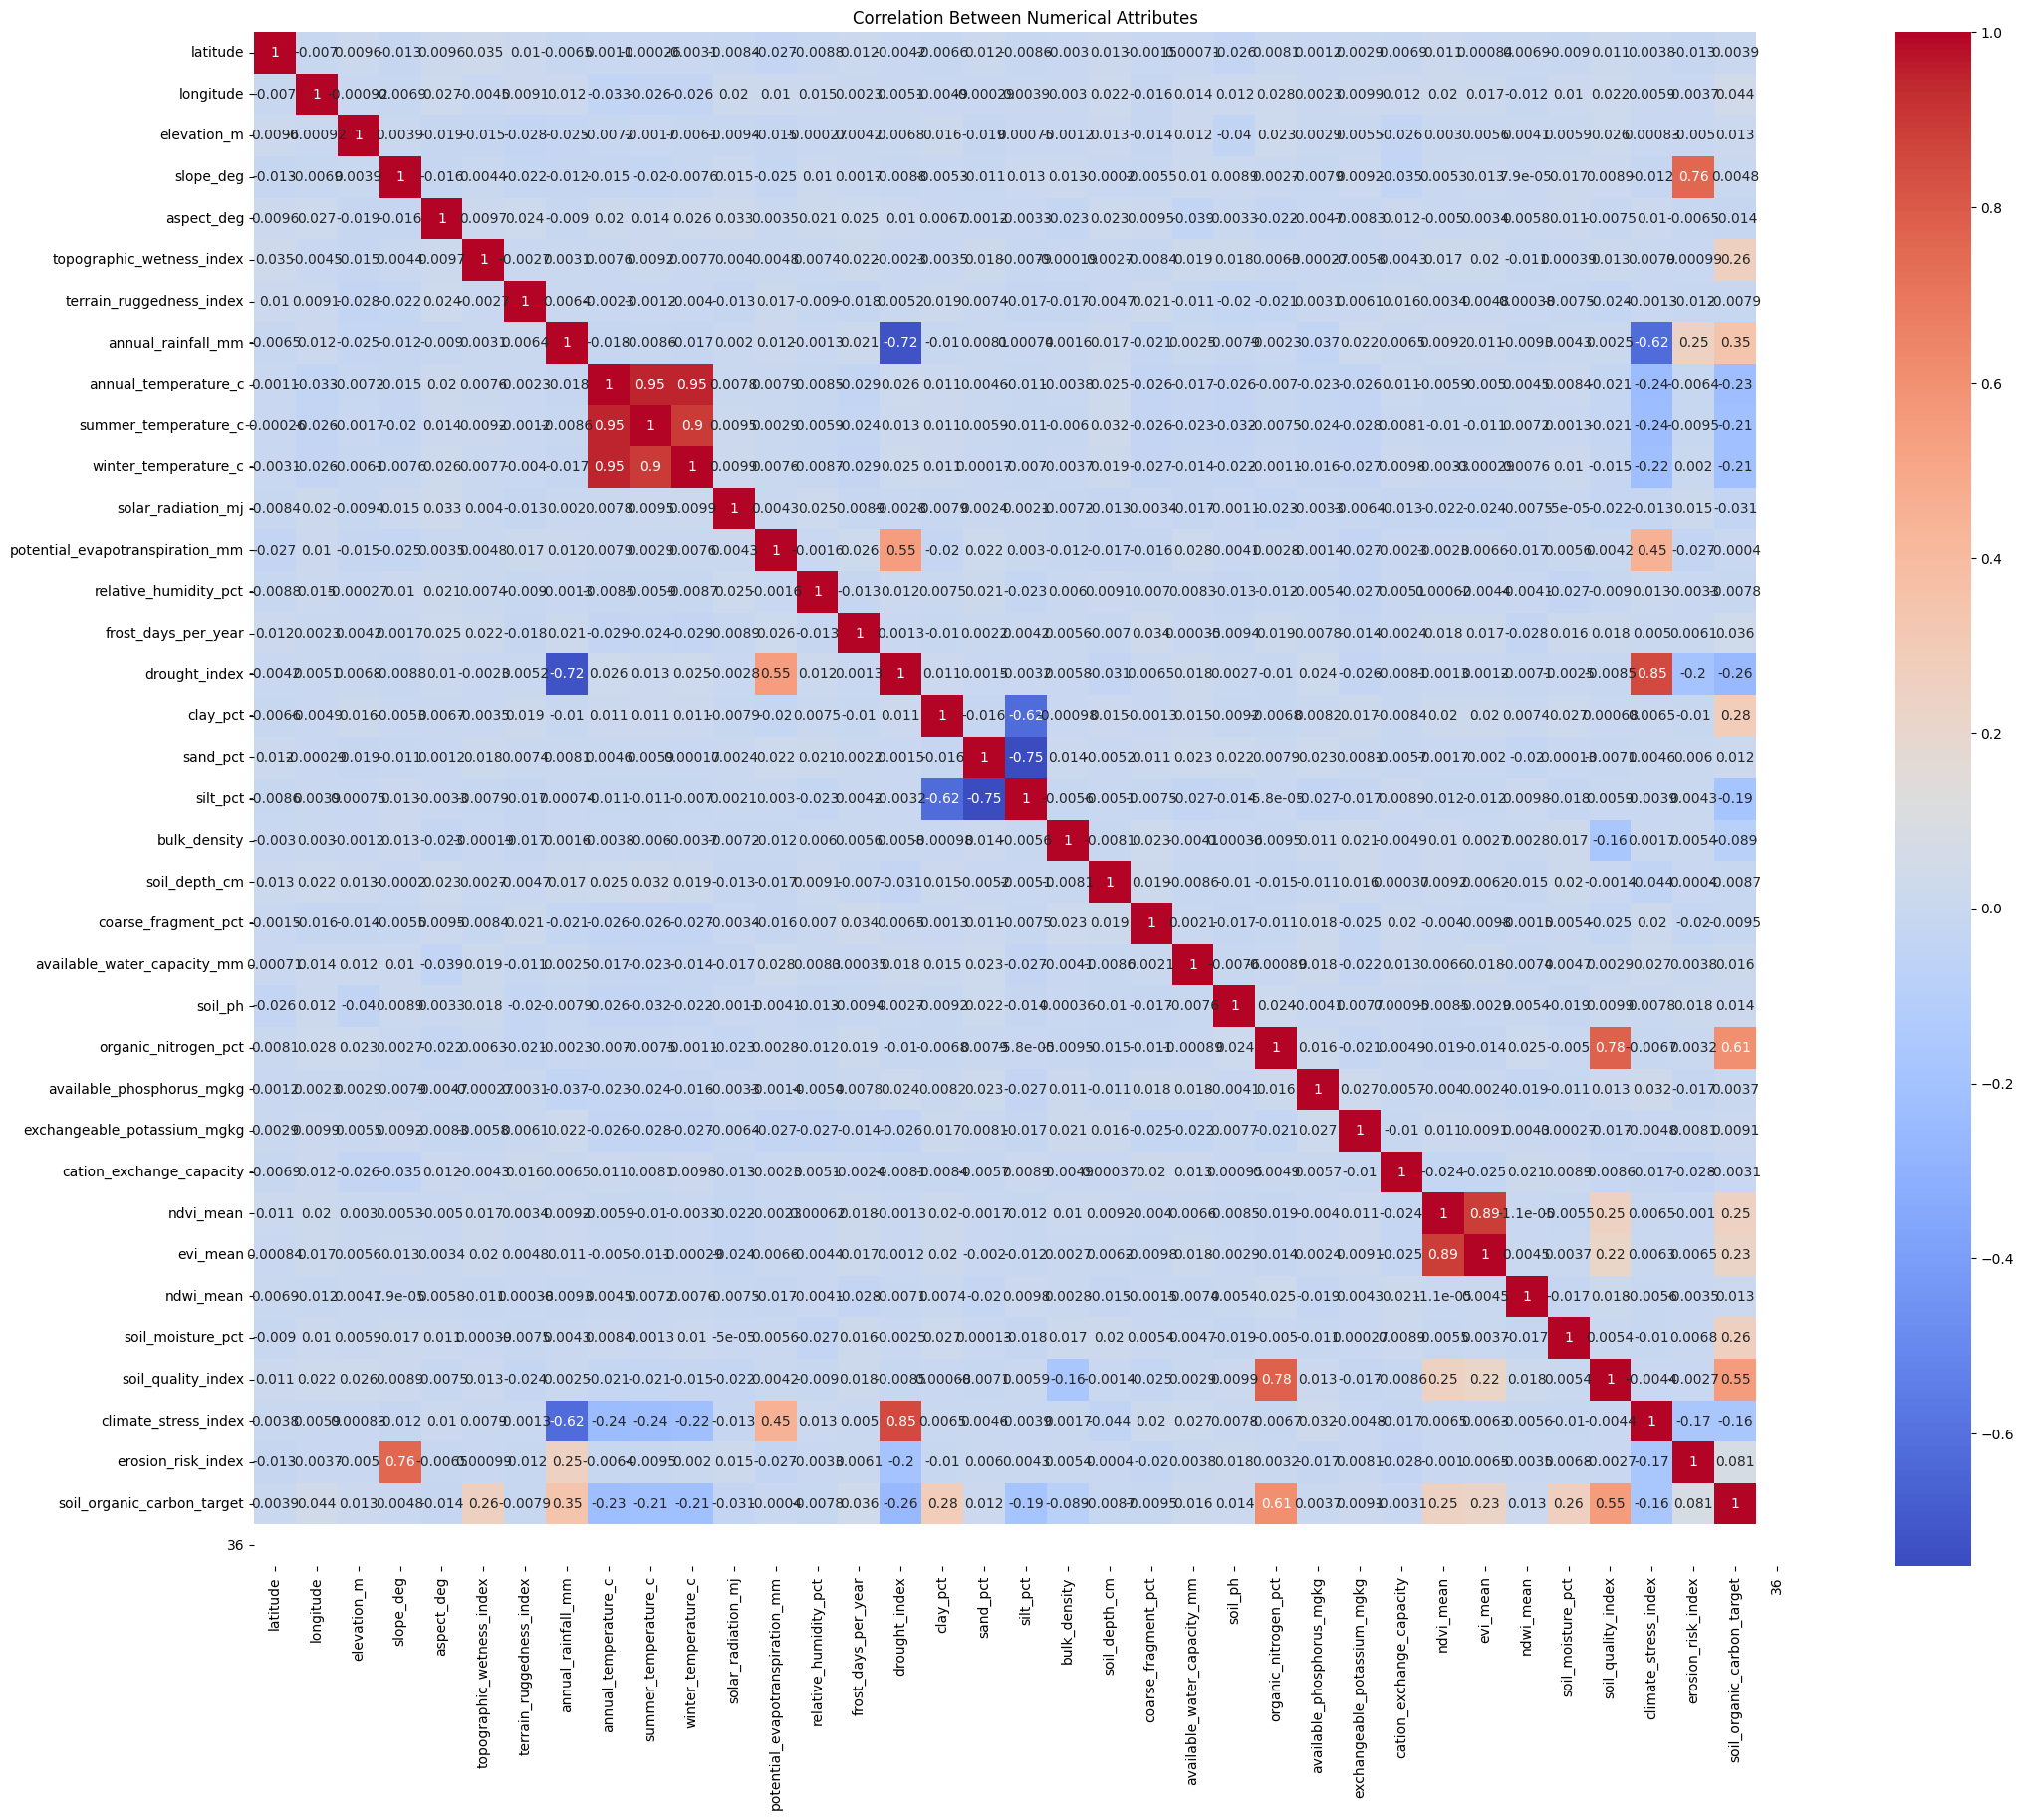

In [8]:

correlation_matrix = df.corr()

# Display
print(correlation_matrix)

# Heatmap visualization
plt.figure(figsize=(25, 20))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Between Numerical Attributes')
plt.show()

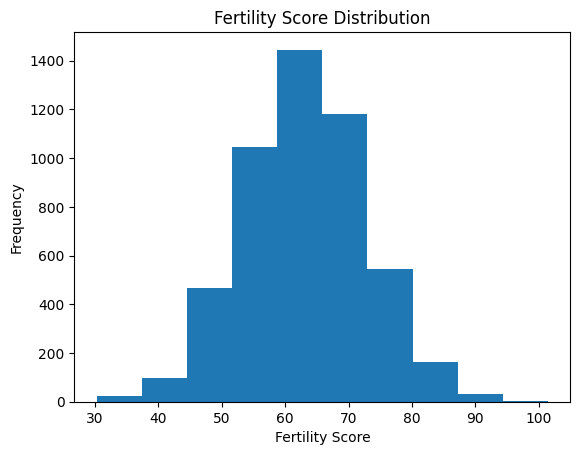

In [9]:
# Histogram
plt.hist(df['soil_organic_carbon_target'], bins=10)
plt.xlabel("Fertility Score")
plt.ylabel("Frequency")
plt.title("Fertility Score Distribution")
plt.show()

From the coorelation of soil_organic_carbon_target with other attributes as below: 

soil_organic_carbon_target  
latitude                                           0.003906  
longitude                                          0.043984  
elevation_m                                        0.012888  
slope_deg                                          0.004802  
aspect_deg                                        -0.013593  
topographic_wetness_index                          0.259220  
terrain_ruggedness_index                          -0.007854  
annual_rainfall_mm                                 0.348765  
annual_temperature_c                              -0.225865  
summer_temperature_c                              -0.210951  
winter_temperature_c                              -0.212998  
solar_radiation_mj                                -0.030879  
potential_evapotranspiration_mm                   -0.000404  
relative_humidity_pct                             -0.007808  
frost_days_per_year                                0.035935  
drought_index                                     -0.256624  
clay_pct                                           0.283623  
sand_pct                                           0.012057  
silt_pct                                          -0.188958  
bulk_density                                      -0.088608  
soil_depth_cm                                     -0.008693  
coarse_fragment_pct                               -0.009517  
available_water_capacity_mm                        0.015788  
soil_ph                                            0.013597  
organic_nitrogen_pct                               0.606452  
available_phosphorus_mgkg                          0.003675  
exchangeable_potassium_mgkg                        0.009128  
cation_exchange_capacity                          -0.003067  
ndvi_mean                                          0.245269  
evi_mean                                           0.227089  
ndwi_mean                                          0.013016  
soil_moisture_pct                                  0.264877  
soil_quality_index                                 0.553208  
climate_stress_index                              -0.164292  
erosion_risk_index                                 0.081103  
soil_organic_carbon_target                         1.000000 


We can see that the following attributes might be the most important parameters: organic_nitrogen_pct
soil_quality_index
annual_rainfall_mm
clay_pct
soil_moisture_pct
topographic_wetness_index
ndvi_mean
evi_mean
erosion_risk_index
and bulk_density
climate_stress_index
silt_pct
summer_temperature_c
winter_temperature_c
annual_temperature_c
drought_index


Task 2.1 Initial model development 
Develop a baseline ANN to predict Soil Organic Carbon (soil_organic_carbon_target) 
using a single hidden layer with 32 neurons with ReLU activation function.  
Compile the model using: 
• Loss Function: Mean Squared Error (MSE)  
• Optimizer: Adam (default learning rate)  
• Evaluation Metric: Mean Absolute Error (MAE)  
Train the model using: 
• Epochs: 100  
• Batch size: 32  
• Validation set: created in Part 1  
Set a random seed prior to training to ensure your results are reproducible. 

separates input features (X) and target labels (y) and then, it splits dataset into three datasets: training dataset, test dataset and validation dataset 60%:20%:20% with the ratio 60% : 20% : 20%.  The datasets are scaled to prepare for the analysis.

In [10]:
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

LabelEncoder

import tensorflow as tf
import tensorflow.keras.backend as K
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam, SGD, Adagrad, RMSprop, Adadelta
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.initializers import RandomNormal
from tensorflow.keras.models import Sequential

from sklearn.model_selection import GridSearchCV
from scikeras.wrappers import KerasClassifier

from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score
import numpy as np

import time
import keras_tuner as kt


In [11]:
import random

# Fix seeds for reproducibility
seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)
random.seed(seed)

# Separate input features (X) and target labels (y)
X = df.drop(columns=['soil_organic_carbon_target', '36']).values # Input features
y = df['soil_organic_carbon_target'].values.reshape(-1, 1) # Target labels

# Splitting the dataset into three datasets for training, testing and validation with the ratio 60% : 20% : 20%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=seed)
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.5, random_state=seed)

# Scaling data
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled  = scaler_X.transform(X_test)
X_val_scaled  = scaler_X.transform(X_val)

y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1))
y_val_scaled = scaler_y.transform(y_val.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1))

In [34]:
### Gradient Descent
# Create a sequential model with input layer which takes the values of 35 input parameters as input, one hidden layer with five neurons using ReLU activation function, and output layer which uses linear activation function to calculate output
gd_model = Sequential([
    Input(shape=(35,)),
    Dense(32, activation='relu', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42)), # Hidden layer with 5 neurons
    Dense(1, activation='linear', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42))
    ])

opt = SGD(learning_rate=0.001, momentum=0.0)

gd_model.compile(
    optimizer=opt,
    loss="mse",
    metrics=["mae"]
)

In [35]:
start_time = time.time()

# Train the model using GD with train dataset and validate the model using validation dataset during training
history_gd = gd_model.fit(
    X_train_scaled,
    y_train_scaled,
    epochs=100,
    batch_size=32, # batch_size > training_dataset_size --> use GD
    validation_data=(X_val_scaled, y_val_scaled),
    verbose=1
)

end_time = time.time()
gd_training_time = end_time - start_time

print(f"Training time: {gd_training_time:.2f} seconds")
print(f"Training time: {gd_training_time/60:.2f} minutes")

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9645 - mae: 0.7825 - val_loss: 0.9185 - val_mae: 0.7629
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9420 - mae: 0.7733 - val_loss: 0.8973 - val_mae: 0.7542
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9176 - mae: 0.7632 - val_loss: 0.8740 - val_mae: 0.7446
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8905 - mae: 0.7518 - val_loss: 0.8478 - val_mae: 0.7339
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8598 - mae: 0.7386 - val_loss: 0.8181 - val_mae: 0.7216
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8249 - mae: 0.7233 - val_loss: 0.7845 - val_mae: 0.7074
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7857 - mae: 0.7056 - val_loss: 0.7468 - val_mae: 0.6910
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7420 - mae: 0.6855 - val_loss: 0.7051 - val_mae: 0.6726
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.694

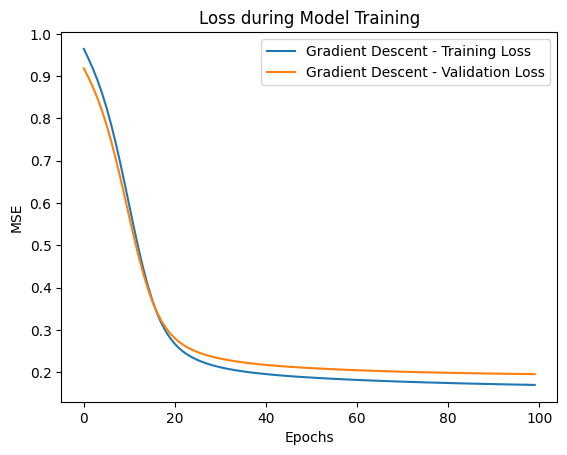

In [36]:
# Plot the training and validation accuracy and loss
plt.plot(history_gd.history["loss"], label="Gradient Descent - Training Loss")
plt.plot(history_gd.history["val_loss"], label="Gradient Descent - Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.title("Loss during Model Training")
plt.legend()
plt.show()

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9970 - mae: 0.7939 - val_loss: 0.7134 - val_mae: 0.6716
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6000 - mae: 0.6149 - val_loss: 0.4816 - val_mae: 0.5578
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4152 - mae: 0.5118 - val_loss: 0.3686 - val_mae: 0.4901
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3231 - mae: 0.4517 - val_loss: 0.3092 - val_mae: 0.4470
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2739 - mae: 0.4157 - val_loss: 0.2757 - val_mae: 0.4211
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2456 - mae: 0.3935 - val_loss: 0.2553 - val_mae: 0.4040
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2282 - mae: 0.3791 - val_loss: 0.2421 - val_mae: 0.3922
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2169 - mae: 0.3693 - val_loss: 0.2331 - val_mae: 0.3846
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.209

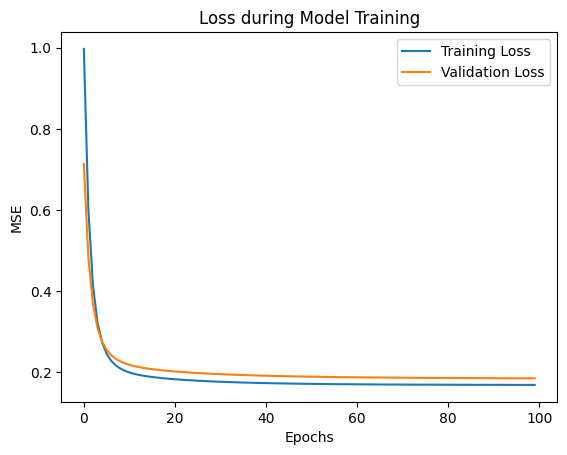

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9645 - mae: 0.7825 - val_loss: 0.9185 - val_mae: 0.7629
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9420 - mae: 0.7733 - val_loss: 0.8973 - val_mae: 0.7542
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.9176 - mae: 0.7632 - val_loss: 0.8740 - val_mae: 0.7446
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8905 - mae: 0.7518 - val_loss: 0.8478 - val_mae: 0.7339
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8598 - mae: 0.7386 - val_loss: 0.8181 - val_mae: 0.7216
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8249 - mae: 0.7233 - val_loss: 0.7845 - val_mae: 0.7074
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7857 - mae: 0.7056 - val_loss: 0.7468 - val_mae: 0.6910
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7420 - mae: 0.6855 - val_loss: 0.7051 - val_mae: 0.6726
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.694

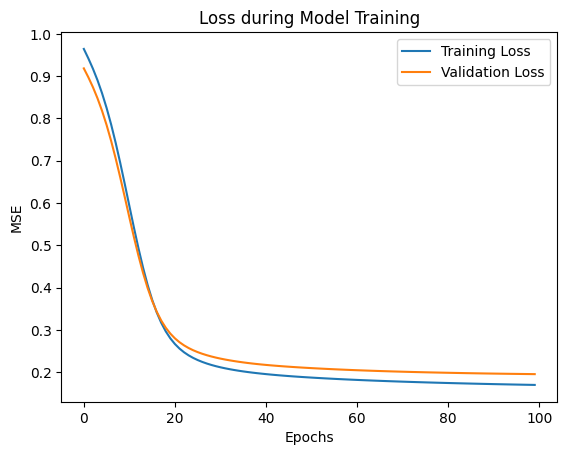

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0002 - mae: 0.7961 - val_loss: 0.9590 - val_mae: 0.7794
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9978 - mae: 0.7952 - val_loss: 0.9567 - val_mae: 0.7779
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9957 - mae: 0.7944 - val_loss: 0.9547 - val_mae: 0.7767
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9939 - mae: 0.7936 - val_loss: 0.9529 - val_mae: 0.7757
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9921 - mae: 0.7929 - val_loss: 0.9511 - val_mae: 0.7748
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9903 - mae: 0.7922 - val_loss: 0.9494 - val_mae: 0.7740
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9885 - mae: 0.7915 - val_loss: 0.9477 - val_mae: 0.7731
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9865 - mae: 0.7907 - val_loss: 0.9458 - val_mae: 0.7723
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.984

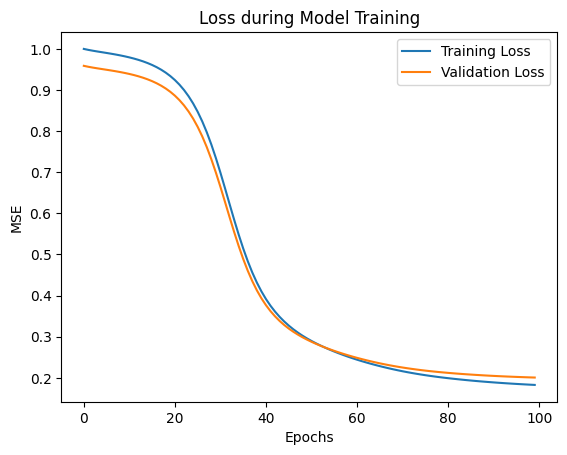

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0019 - mae: 0.7966 - val_loss: 0.9596 - val_mae: 0.7789
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0013 - mae: 0.7964 - val_loss: 0.9589 - val_mae: 0.7783
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0008 - mae: 0.7962 - val_loss: 0.9584 - val_mae: 0.7778
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0005 - mae: 0.7961 - val_loss: 0.9580 - val_mae: 0.7775
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0003 - mae: 0.7960 - val_loss: 0.9577 - val_mae: 0.7772
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0002 - mae: 0.7960 - val_loss: 0.9574 - val_mae: 0.7770
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0000 - mae: 0.7959 - val_loss: 0.9572 - val_mae: 0.7768
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9999 - mae: 0.7959 - val_loss: 0.9571 - val_mae: 0.7766
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.999

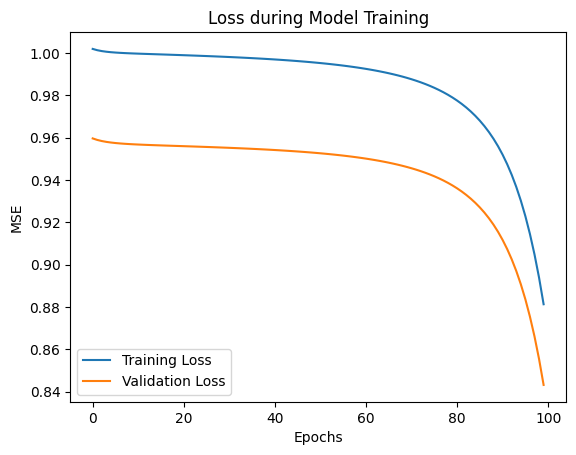

In [37]:
histories = {}
n_layers = [1,2,3,4]




for no_of_layers in n_layers:
# Create a sequential model with input layer which takes the values of 35 input parameters as input, one hidden layer with one neuron, and output layer which uses linear activation function to calculate output
    
    model = Sequential([
    Input(shape=(35,))])

    for i in range(1,no_of_layers):
        model.add(Dense(32, activation='relu', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42))) # Hidden layer with 5 neurons

    model.add(Dense(1, activation='linear', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42)))
    

    
    opt = SGD(learning_rate=0.001, momentum=0.0)

    model.compile(
        optimizer=opt,
        loss='mse',
        metrics=['mae']
)

    # Train the model using GD with train dataset and validate the model using validation dataset during training
    start_time = time.time()

    history_model = model.fit(
        X_train_scaled,
        y_train_scaled,
        epochs=100,
        batch_size=32, # batch_size > training_dataset_size --> use GD
        validation_data=(X_val_scaled, y_val_scaled),
        verbose=1
    )

    end_time = time.time()
    training_time = end_time - start_time

 


    
    histories[no_of_layers] = history_model

    # make Predictions using the Model
    y_true = y_test
    y_pred = np.argmax(model.predict(X_test_scaled), axis=1) # convert probabilities to class labels

    y_prob = model.predict(X_test_scaled)
    
    print('-----------------------------------------------------------------------------------------------------------------------')
    print('The results with %f no. of layers', no_of_layers)
    print('-----------------------------------------------------------------------------------------------------------------------')

   
   
   # Plot the training and validation accuracy and loss
    plt.plot(history_model.history["loss"], label="Training Loss")
    plt.plot(history_model.history["val_loss"], label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("MSE")
    plt.title("Loss during Model Training")
    plt.legend()
    plt.show()

  










From the analysis above, when the layers increase from 1 to 4, both msa and mae increased, so I will keep at one hidden layer. In the next step I will investigate the effect of varying the number of neurons per hidden layers. I will try with 16, 32, 64 and 128 neurons. 

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0037 - mae: 0.7980 - val_loss: 0.9596 - val_mae: 0.7787
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9947 - mae: 0.7944 - val_loss: 0.9515 - val_mae: 0.7752
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9858 - mae: 0.7909 - val_loss: 0.9432 - val_mae: 0.7717
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9764 - mae: 0.7871 - val_loss: 0.9343 - val_mae: 0.7681
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9659 - mae: 0.7829 - val_loss: 0.9243 - val_mae: 0.7641
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9538 - mae: 0.7781 - val_loss: 0.9127 - val_mae: 0.7594
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9397 - mae: 0.7723 - val_loss: 0.8989 - val_mae: 0.7539
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9229 - mae: 0.7654 - val_loss: 0.8826 - val_mae: 0.7474
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.903

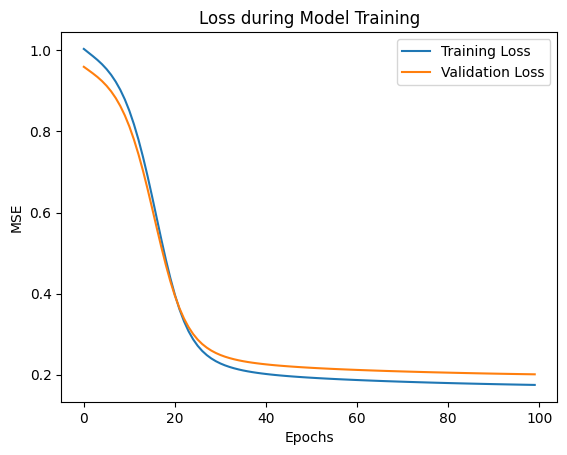

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.9645 - mae: 0.7825 - val_loss: 0.9185 - val_mae: 0.7629
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9420 - mae: 0.7733 - val_loss: 0.8973 - val_mae: 0.7542
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9176 - mae: 0.7632 - val_loss: 0.8740 - val_mae: 0.7446
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8905 - mae: 0.7518 - val_loss: 0.8478 - val_mae: 0.7339
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8598 - mae: 0.7386 - val_loss: 0.8181 - val_mae: 0.7216
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8249 - mae: 0.7233 - val_loss: 0.7845 - val_mae: 0.7074
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7857 - mae: 0.7056 - val_loss: 0.7468 - val_mae: 0.6910
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7420 - mae: 0.6855 - val_loss: 0.7051 - val_mae: 0.6726
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.694

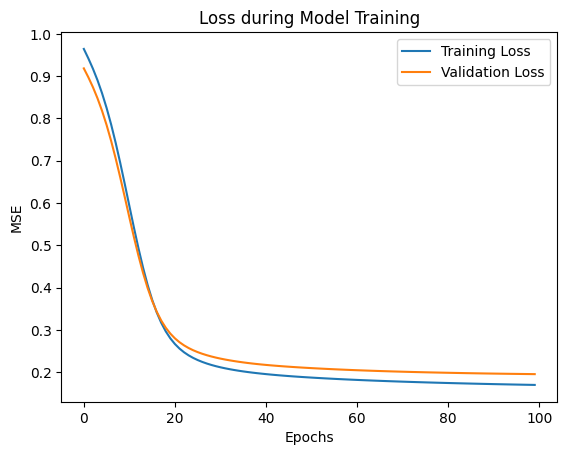

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.0269 - mae: 0.8072 - val_loss: 0.9667 - val_mae: 0.7845
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9827 - mae: 0.7895 - val_loss: 0.9278 - val_mae: 0.7679
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9427 - mae: 0.7733 - val_loss: 0.8915 - val_mae: 0.7524
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9036 - mae: 0.7570 - val_loss: 0.8552 - val_mae: 0.7368
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8636 - mae: 0.7400 - val_loss: 0.8174 - val_mae: 0.7205
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8217 - mae: 0.7218 - val_loss: 0.7775 - val_mae: 0.7029
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7773 - mae: 0.7020 - val_loss: 0.7351 - val_mae: 0.6841
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7303 - mae: 0.6802 - val_loss: 0.6903 - val_mae: 0.6637
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.681

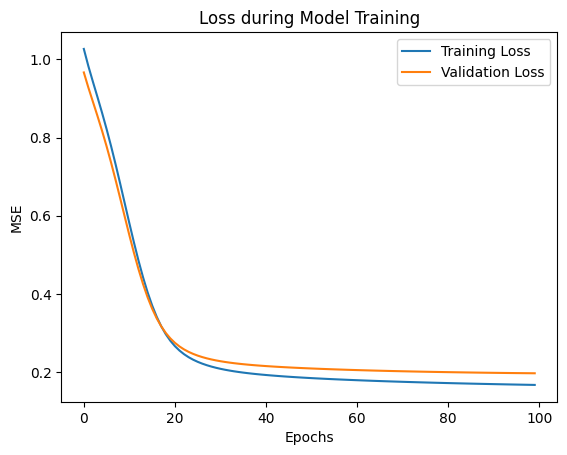

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.0595 - mae: 0.8230 - val_loss: 0.9780 - val_mae: 0.7919
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9580 - mae: 0.7832 - val_loss: 0.8952 - val_mae: 0.7571
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8770 - mae: 0.7498 - val_loss: 0.8251 - val_mae: 0.7268
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8046 - mae: 0.7184 - val_loss: 0.7607 - val_mae: 0.6982
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7365 - mae: 0.6873 - val_loss: 0.6994 - val_mae: 0.6701
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6712 - mae: 0.6559 - val_loss: 0.6406 - val_mae: 0.6422
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6088 - mae: 0.6241 - val_loss: 0.5846 - val_mae: 0.6142
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5500 - mae: 0.5924 - val_loss: 0.5321 - val_mae: 0.5864
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.495

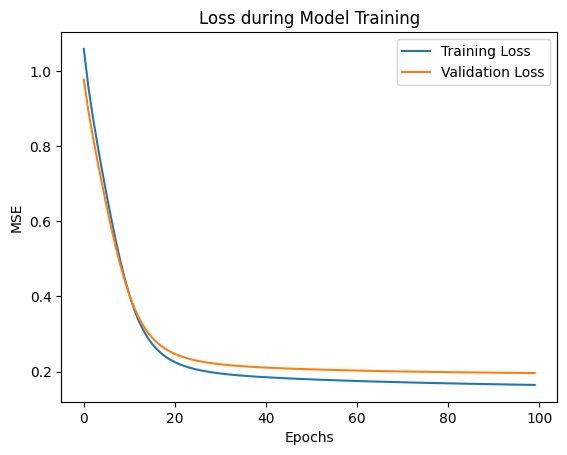

In [38]:
histories = {}
n_neuron = [16,32,64,128]




for no_of_neuron in n_neuron:
# Create a sequential model with input layer which takes the values of 35 input parameters as input, one hidden layer with one neuron, and output layer which uses linear activation function to calculate output
    
    model = Sequential([
    Input(shape=(35,))])

    model.add(Dense(no_of_neuron, activation='relu', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42))) # Hidden layer with 5 neurons

    model.add(Dense(1, activation='linear', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42)))
    

    
    opt = SGD(learning_rate=0.001, momentum=0.0)

    model.compile(
        optimizer=opt,
        loss='mse',
        metrics=['mae']
)

    # Train the model using GD with train dataset and validate the model using validation dataset during training
    start_time = time.time()

    history_model = model.fit(
        X_train_scaled,
        y_train_scaled,
        epochs=100,
        batch_size=32, # batch_size > training_dataset_size --> use GD
        validation_data=(X_val_scaled, y_val_scaled),
        verbose=1
    )

    end_time = time.time()
    training_time = end_time - start_time

 


    
    histories[no_of_neuron] = history_model

    # make Predictions using the Model
    y_true = y_test
    y_pred = np.argmax(model.predict(X_test_scaled), axis=1) # convert probabilities to class labels

    y_prob = model.predict(X_test_scaled)
    
    print('-----------------------------------------------------------------------------------------------------------------------')
    print('The results with %f no. of neuron', no_of_neuron)
    print('-----------------------------------------------------------------------------------------------------------------------')

   
   
   # Plot the training and validation accuracy and loss
    plt.plot(history_model.history["loss"], label="Training Loss")
    plt.plot(history_model.history["val_loss"], label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("MSE")
    plt.title("Loss during Model Training")
    plt.legend()
    plt.show()

  










So, we can see that with no of neuron being 128 we have the least mse and mae. So we will choose the model with one layer and 128 neurons. In the next step, we will use this best architecture so far to evaluate the effect of different activation 
functions. I will test the following activation fuctions: ReLU, tanh, and sigmoid

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.0595 - mae: 0.8230 - val_loss: 0.9780 - val_mae: 0.7919
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9580 - mae: 0.7832 - val_loss: 0.8952 - val_mae: 0.7571
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8770 - mae: 0.7498 - val_loss: 0.8251 - val_mae: 0.7268
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8046 - mae: 0.7184 - val_loss: 0.7607 - val_mae: 0.6982
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7365 - mae: 0.6873 - val_loss: 0.6994 - val_mae: 0.6701
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6712 - mae: 0.6559 - val_loss: 0.6406 - val_mae: 0.6422
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6088 - mae: 0.6241 - val_loss: 0.5846 - val_mae: 0.6142
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5500 - mae: 0.5924 - val_loss: 0.5321 - val_mae: 0.5864
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.495

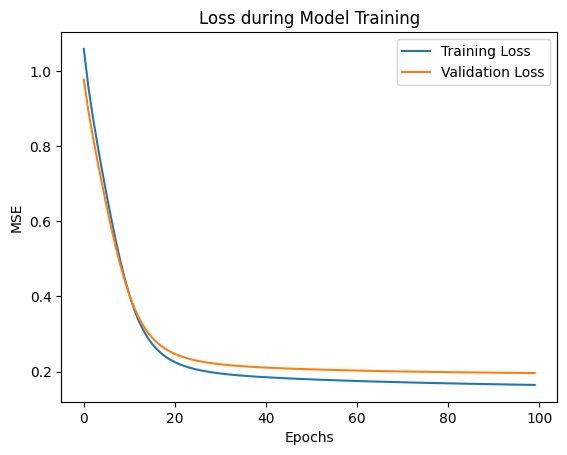

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.0972 - mae: 0.8383 - val_loss: 0.9341 - val_mae: 0.7836
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8316 - mae: 0.7308 - val_loss: 0.7344 - val_mae: 0.6944
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6536 - mae: 0.6476 - val_loss: 0.5921 - val_mae: 0.6232
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5238 - mae: 0.5792 - val_loss: 0.4863 - val_mae: 0.5638
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4279 - mae: 0.5223 - val_loss: 0.4080 - val_mae: 0.5156
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3583 - mae: 0.4766 - val_loss: 0.3512 - val_mae: 0.4773
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3089 - mae: 0.4413 - val_loss: 0.3107 - val_mae: 0.4466
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2742 - mae: 0.4150 - val_loss: 0.2820 - val_mae: 0.4243
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.250

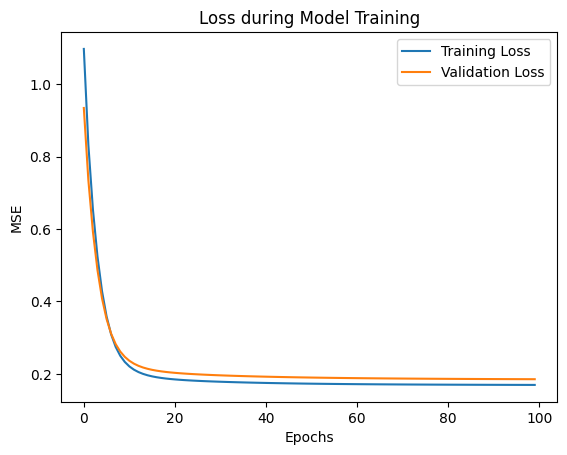

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.0235 - mae: 0.8072 - val_loss: 0.9719 - val_mae: 0.7847
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0012 - mae: 0.7986 - val_loss: 0.9529 - val_mae: 0.7771
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9806 - mae: 0.7902 - val_loss: 0.9345 - val_mae: 0.7696
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9604 - mae: 0.7820 - val_loss: 0.9164 - val_mae: 0.7623
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9404 - mae: 0.7737 - val_loss: 0.8983 - val_mae: 0.7549
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9205 - mae: 0.7655 - val_loss: 0.8803 - val_mae: 0.7474
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9004 - mae: 0.7570 - val_loss: 0.8620 - val_mae: 0.7397
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8801 - mae: 0.7484 - val_loss: 0.8434 - val_mae: 0.7319
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.859

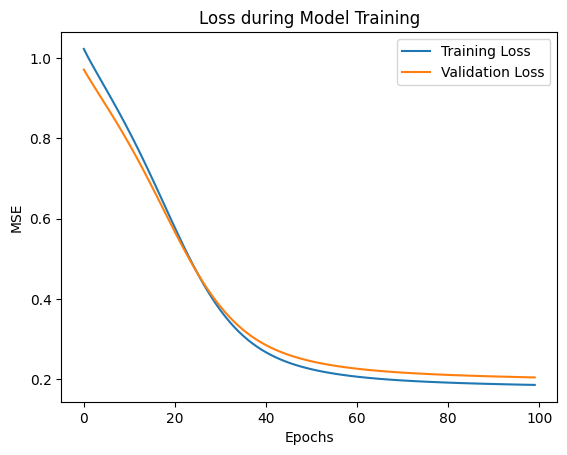

In [39]:
histories = {}
activation_function = ['relu','tanh','sigmoid']




for activation in activation_function:
# Create a sequential model with input layer which takes the values of 35 input parameters as input, one hidden layer with one neuron, and output layer which uses linear activation function to calculate output
    
    model = Sequential([
    Input(shape=(35,))])

    model.add(Dense(128, activation=activation, kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42))) # Hidden layer with 5 neurons

    model.add(Dense(1, activation='linear', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42)))
    

    
    opt = SGD(learning_rate=0.001, momentum=0.0)

    model.compile(
        optimizer=opt,
        loss='mse',
        metrics=['mae']
)

    # Train the model using GD with train dataset and validate the model using validation dataset during training
    start_time = time.time()

    history_model = model.fit(
        X_train_scaled,
        y_train_scaled,
        epochs=100,
        batch_size=32, # batch_size > training_dataset_size --> use GD
        validation_data=(X_val_scaled, y_val_scaled),
        verbose=1
    )

    end_time = time.time()
    training_time = end_time - start_time

 


    
    histories[activation] = history_model

    # make Predictions using the Model
    y_true = y_test
    y_pred = np.argmax(model.predict(X_test_scaled), axis=1) # convert probabilities to class labels

    y_prob = model.predict(X_test_scaled)
    
    print('-----------------------------------------------------------------------------------------------------------------------')
    print('The results with %f activation function', activation)
    print('-----------------------------------------------------------------------------------------------------------------------')

   
   
   # Plot the training and validation accuracy and loss
    plt.plot(history_model.history["loss"], label="Training Loss")
    plt.plot(history_model.history["val_loss"], label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("MSE")
    plt.title("Loss during Model Training")
    plt.legend()
    plt.show()

  










So we can see that the acivation of tanh gives us the lowest mae amd loss so we will use tanh as the activation. So our best model so far has one hidden layer, 128 neurons and activation of tanh. 

In [40]:
### Gradient Descent
# Create a sequential model with input layer which takes the values of 35 input parameters as input, one hidden layer with five neurons using ReLU activation function, and output layer which uses linear activation function to calculate output
gd_model = Sequential([
    Input(shape=(35,)),
    Dense(128, activation='tanh', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42)), # Hidden layer with 5 neurons
    Dense(1, activation='linear', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42))
    ])

opt = SGD(learning_rate=0.001, momentum=0.0)

gd_model.compile(
    optimizer=opt,
    loss="mse",
    metrics=["mae"]
)

start_time = time.time()

# Train the model using GD with train dataset and validate the model using validation dataset during training
history_gd = gd_model.fit(
    X_train_scaled,
    y_train_scaled,
    epochs=100,
    batch_size=32, # batch_size > training_dataset_size --> use GD
    validation_data=(X_val_scaled, y_val_scaled),
    verbose=1
)

end_time = time.time()
gd_training_time = end_time - start_time

print(f"Training time: {gd_training_time:.2f} seconds")
print(f"Training time: {gd_training_time/60:.2f} minutes")

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0972 - mae: 0.8383 - val_loss: 0.9341 - val_mae: 0.7836
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8316 - mae: 0.7308 - val_loss: 0.7344 - val_mae: 0.6944
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6536 - mae: 0.6476 - val_loss: 0.5921 - val_mae: 0.6232
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5238 - mae: 0.5792 - val_loss: 0.4863 - val_mae: 0.5638
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4279 - mae: 0.5223 - val_loss: 0.4080 - val_mae: 0.5156
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3583 - mae: 0.4766 - val_loss: 0.3512 - val_mae: 0.4773
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3089 - mae: 0.4413 - val_loss: 0.3107 - val_mae: 0.4466
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2742 - mae: 0.4150 - val_loss: 0.2820 - val_mae: 0.4243
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.250

In the next step I will investigate the effect of different optimisation algorithms, including appropriate 
tuning of their associated hyperparameters. There are three optimisation algorithms that I will investigate. They are Adam, Adagrad, RMSprob. First we check with Adam optimiser. 

In [56]:



# Create a sequential model with input layer which takes the values of 35 input parameters as input, one hidden layer with one neuron, and output layer which uses linear activation function to calculate output
model_adam = Sequential([
    Input(shape=(35,)),
    Dense(128, activation='tanh', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42)), # Hidden layer with 5 neurons
    Dense(1, activation='linear', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42))
    ])

opt = Adam(learning_rate=0.01)

model_adam.compile(
    optimizer=opt,
    loss="mse",
    metrics=['mae']
)

# Train the model using GD with train dataset and validate the model using validation dataset during training
start_time = time.time()

history_adam = model_adam.fit(
    X_train_scaled,
    y_train_scaled,
    epochs=100,
    batch_size=32, # batch_size > training_dataset_size --> use GD
    validation_data=(X_val_scaled, y_val_scaled),
    verbose=1
)

end_time = time.time()
training_time = end_time - start_time

print(f"Training time: {training_time:.2f} seconds")
print(f"Training time: {training_time/60:.2f} minutes")

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2473 - mae: 0.3908 - val_loss: 0.2600 - val_mae: 0.4071
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2072 - mae: 0.3603 - val_loss: 0.2536 - val_mae: 0.4028
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2043 - mae: 0.3580 - val_loss: 0.2525 - val_mae: 0.4015
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1999 - mae: 0.3546 - val_loss: 0.2508 - val_mae: 0.3995
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1967 - mae: 0.3527 - val_loss: 0.2590 - val_mae: 0.4054
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1920 - mae: 0.3479 - val_loss: 0.2326 - val_mae: 0.3840
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1877 - mae: 0.3420 - val_loss: 0.2461 - val_mae: 0.3940
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1739 - mae: 0.3309 - val_loss: 0.2527 - val_mae: 0.3981
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.165

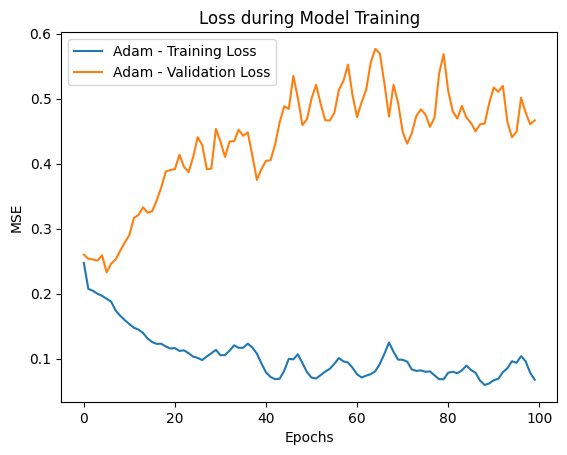

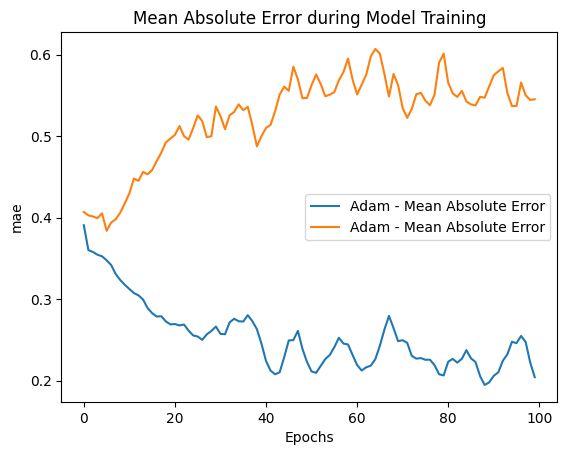

In [57]:
# Plot the training and validation accuracy and loss
plt.plot(history_adam.history["loss"], label="Adam - Training Loss")
plt.plot(history_adam.history["val_loss"], label="Adam - Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.title("Loss during Model Training")
plt.legend()
plt.show()

plt.plot(history_adam.history["mae"], label="Adam - Mean Absolute Error")
plt.plot(history_adam.history["val_mae"], label="Adam - Mean Absolute Error")
plt.xlabel("Epochs")
plt.ylabel("mae")
plt.title("Mean Absolute Error during Model Training")
plt.legend()
plt.show()

So we can see that with Adam optimizer learning rate 0.01 we can have r2_score very high but the model looks overfitting with val_r2_score reduce 

In the next step, I tried adam optimizer with a smaller learning rate which is 0.001 

In [58]:



# Create a sequential model with input layer which takes the values of 35 input parameters as input, one hidden layer with one neuron, and output layer which uses linear activation function to calculate output
model_adam = Sequential([
    Input(shape=(35,)),
    Dense(128, activation='tanh', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42)), # Hidden layer with 5 neurons
    Dense(1, activation='linear', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42))
    ])

opt = Adam(learning_rate=0.001)

model_adam.compile(
    optimizer=opt,
    loss="mse",
    metrics=['mae']
)

# Train the model using GD with train dataset and validate the model using validation dataset during training
start_time = time.time()

history_adam = model_adam.fit(
    X_train_scaled,
    y_train_scaled,
    epochs=100,
    batch_size=32, # batch_size > training_dataset_size --> use GD
    validation_data=(X_val_scaled, y_val_scaled),
    verbose=1
)

end_time = time.time()
training_time = end_time - start_time

print(f"Training time: {training_time:.2f} seconds")
print(f"Training time: {training_time/60:.2f} minutes")

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3969 - mae: 0.4826 - val_loss: 0.2124 - val_mae: 0.3668
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1895 - mae: 0.3453 - val_loss: 0.1971 - val_mae: 0.3537
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1813 - mae: 0.3365 - val_loss: 0.1924 - val_mae: 0.3498
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1791 - mae: 0.3337 - val_loss: 0.1909 - val_mae: 0.3486
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1782 - mae: 0.3327 - val_loss: 0.1902 - val_mae: 0.3481
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1777 - mae: 0.3321 - val_loss: 0.1898 - val_mae: 0.3478
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1772 - mae: 0.3315 - val_loss: 0.1895 - val_mae: 0.3476
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1767 - mae: 0.3310 - val_loss: 0.1893 - val_mae: 0.3475
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.176

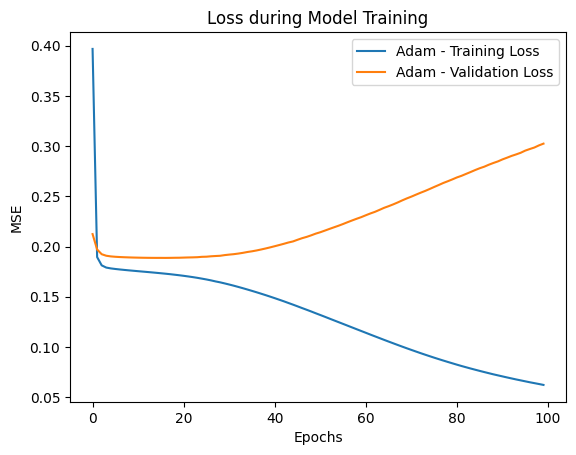

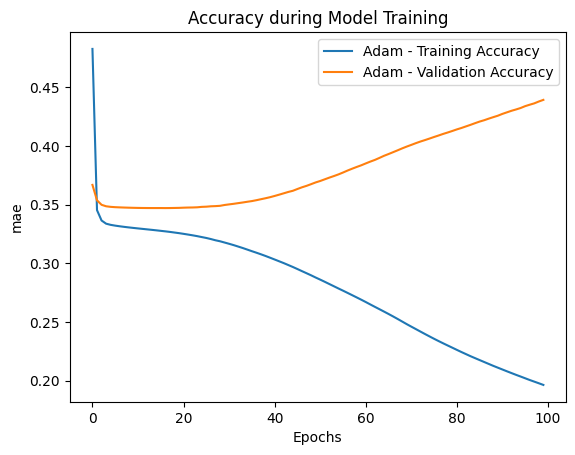

In [59]:
# Plot the training and validation accuracy and loss
plt.plot(history_adam.history["loss"], label="Adam - Training Loss")
plt.plot(history_adam.history["val_loss"], label="Adam - Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.title("Loss during Model Training")
plt.legend()
plt.show()

plt.plot(history_adam.history["mae"], label="Adam - Training Accuracy")
plt.plot(history_adam.history["val_mae"], label="Adam - Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("mae")
plt.title("Accuracy during Model Training")
plt.legend()
plt.show()

With adam with learning rate of 0.001, we can see that the R2_score train and validation both higher than Adam learning rate of 0.01. We will test the model with learning rate even smaller 0.0001 to chekc if we can have the score higher. 

In [60]:


# Create a sequential model with input layer which takes the values of 35 input parameters as input, one hidden layer with one neuron, and output layer which uses linear activation function to calculate output
model_adam = Sequential([
    Input(shape=(35,)),
    Dense(128, activation='tanh', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42)), # Hidden layer with 5 neurons
    Dense(1, activation='linear', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42))
    ])

opt = Adam(learning_rate=0.0001)

model_adam.compile(
    optimizer=opt,
    loss="mse",
    metrics=['mae']
)

# Train the model using GD with train dataset and validate the model using validation dataset during training
start_time = time.time()

history_adam = model_adam.fit(
    X_train_scaled,
    y_train_scaled,
    epochs=100,
    batch_size=32, # batch_size > training_dataset_size --> use GD
    validation_data=(X_val_scaled, y_val_scaled),
    verbose=1
)

end_time = time.time()
training_time = end_time - start_time

print(f"Training time: {training_time:.2f} seconds")
print(f"Training time: {training_time/60:.2f} minutes")

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.0663 - mae: 0.8247 - val_loss: 0.8754 - val_mae: 0.7604
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7423 - mae: 0.6865 - val_loss: 0.6208 - val_mae: 0.6410
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5144 - mae: 0.5711 - val_loss: 0.4402 - val_mae: 0.5380
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3626 - mae: 0.4787 - val_loss: 0.3259 - val_mae: 0.4605
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2736 - mae: 0.4154 - val_loss: 0.2628 - val_mae: 0.4124
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2278 - mae: 0.3791 - val_loss: 0.2321 - val_mae: 0.3865
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2065 - mae: 0.3608 - val_loss: 0.2182 - val_mae: 0.3732
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1968 - mae: 0.3519 - val_loss: 0.2115 - val_mae: 0.3667
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.191

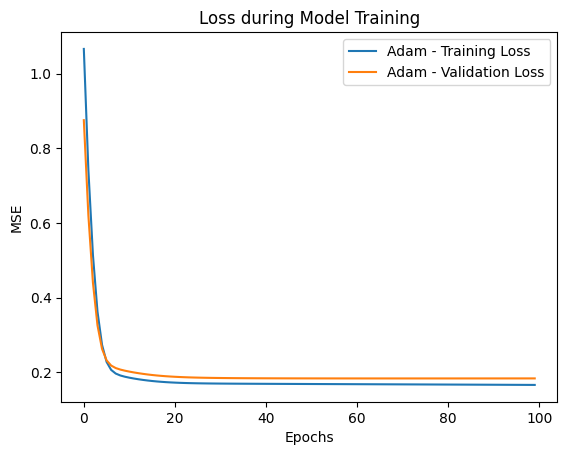

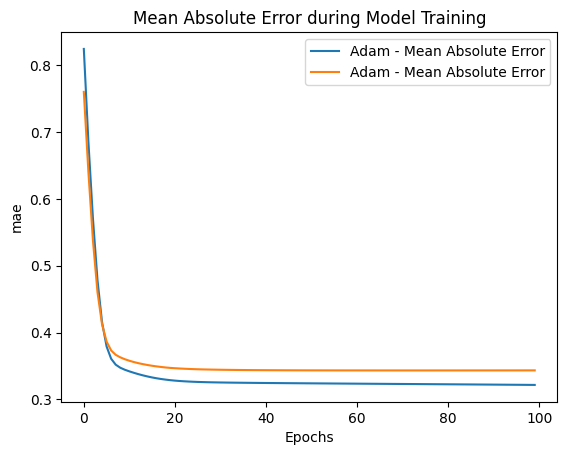

In [61]:
# Plot the training and validation accuracy and loss
plt.plot(history_adam.history["loss"], label="Adam - Training Loss")
plt.plot(history_adam.history["val_loss"], label="Adam - Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.title("Loss during Model Training")
plt.legend()
plt.show()

plt.plot(history_adam.history["mae"], label="Adam - Mean Absolute Error")
plt.plot(history_adam.history["val_mae"], label="Adam - Mean Absolute Error")
plt.xlabel("Epochs")
plt.ylabel("mae")
plt.title("Mean Absolute Error during Model Training")
plt.legend()
plt.show()

We can see that with the learning rate of 0.0001, the mean absolute error and loss of val_date and train_data are smaller. Therefore, I will do another ADam optimizer with learning rate of 0.00001 

In [62]:



# Create a sequential model with input layer which takes the values of 35 input parameters as input, one hidden layer with one neuron, and output layer which uses linear activation function to calculate output
model_adam = Sequential([
    Input(shape=(35,)),
    Dense(128, activation='tanh', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42)), # Hidden layer with 5 neurons
    Dense(1, activation='linear', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42))
    ])

opt = Adam(learning_rate=0.00001)

model_adam.compile(
    optimizer=opt,
    loss="mse",
    metrics=['mae']
)

# Train the model using GD with train dataset and validate the model using validation dataset during training
start_time = time.time()

history_adam = model_adam.fit(
    X_train_scaled,
    y_train_scaled,
    epochs=100,
    batch_size=32, # batch_size > training_dataset_size --> use GD
    validation_data=(X_val_scaled, y_val_scaled),
    verbose=1
)

end_time = time.time()
training_time = end_time - start_time

print(f"Training time: {training_time:.2f} seconds")
print(f"Training time: {training_time/60:.2f} minutes")

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.2538 - mae: 0.8973 - val_loss: 1.2088 - val_mae: 0.8925
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.2079 - mae: 0.8806 - val_loss: 1.1667 - val_mae: 0.8770
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1643 - mae: 0.8645 - val_loss: 1.1266 - val_mae: 0.8618
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1226 - mae: 0.8488 - val_loss: 1.0882 - val_mae: 0.8472
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0827 - mae: 0.8334 - val_loss: 1.0514 - val_mae: 0.8328
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0444 - mae: 0.8183 - val_loss: 1.0160 - val_mae: 0.8187
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0076 - mae: 0.8035 - val_loss: 0.9818 - val_mae: 0.8049
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9720 - mae: 0.7890 - val_loss: 0.9488 - val_mae: 0.7914
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.937

With the learning rate of 0.00001, both loss and absolute mean error for train and val data lower than with the adam of learning rate of 0.0001. So for Adam I will choose the learning rate of 0.0001. In the next step I will try the adagrad optimizer. First with the learning rate of 0.01

In [63]:
# Model
model_adagrad = Sequential([
    Dense(128, activation='tanh', input_shape=(35,), kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42)),
    
    Dense(1)
])

opt = Adagrad(learning_rate=0.01)

# Compile with AdaGrad
model_adagrad.compile(
    optimizer=opt,
    loss='mse',
    metrics=['mae']
)

# Train
start_time = time.time()

history_adagrad = model_adagrad.fit(
    X_train_scaled, 
    y_train_scaled, 
    epochs=100, 
    batch_size=32, 
    validation_data=(X_val_scaled, y_val_scaled)
)

end_time = time.time()
adagrad_training_time = end_time - start_time

print(f"Training time: {adagrad_training_time:.2f} seconds")
print(f"Training time: {adagrad_training_time/60:.2f} minutes")

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2300 - mae: 0.3748 - val_loss: 0.2015 - val_mae: 0.3583
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1811 - mae: 0.3367 - val_loss: 0.1976 - val_mae: 0.3547
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1784 - mae: 0.3338 - val_loss: 0.1957 - val_mae: 0.3529
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1770 - mae: 0.3323 - val_loss: 0.1944 - val_mae: 0.3518
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1760 - mae: 0.3312 - val_loss: 0.1934 - val_mae: 0.3509
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1751 - mae: 0.3303 - val_loss: 0.1926 - val_mae: 0.3503
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1744 - mae: 0.3296 - val_loss: 0.1919 - val_mae: 0.3497
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1739 - mae: 0.3290 - val_loss: 0.1914 - val_mae: 0.3493
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.173

The optimizer of Agradad (learning rate 0.01) gave loss and mae just slighlty higher than Adam (with learning rate of 0.0001). I will try Agradad with learning rate 0.001

In [64]:
# Model
model_adagrad = Sequential([
    Dense(128, activation='tanh', input_shape=(35,), kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42)),
    
    Dense(1)
])

opt = Adagrad(learning_rate=0.001)

# Compile with AdaGrad
model_adagrad.compile(
    optimizer=opt,
    loss='mse',
    metrics=['mae']
)

# Train
start_time = time.time()

history_adagrad = model_adagrad.fit(
    X_train_scaled, 
    y_train_scaled, 
    epochs=100, 
    batch_size=32, 
    validation_data=(X_val_scaled, y_val_scaled)
)

end_time = time.time()
adagrad_training_time = end_time - start_time

print(f"Training time: {adagrad_training_time:.2f} seconds")
print(f"Training time: {adagrad_training_time/60:.2f} minutes")

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6175 - mae: 0.6144 - val_loss: 0.4137 - val_mae: 0.5178
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3334 - mae: 0.4556 - val_loss: 0.3009 - val_mae: 0.4411
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2589 - mae: 0.4029 - val_loss: 0.2593 - val_mae: 0.4070
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2294 - mae: 0.3803 - val_loss: 0.2407 - val_mae: 0.3913
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2157 - mae: 0.3694 - val_loss: 0.2310 - val_mae: 0.3833
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2082 - mae: 0.3632 - val_loss: 0.2252 - val_mae: 0.3784
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2035 - mae: 0.3591 - val_loss: 0.2212 - val_mae: 0.3748
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2000 - mae: 0.3560 - val_loss: 0.2181 - val_mae: 0.3720
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.197

So with the learning rate 0.001 the loss and mae of val_date is still a little higher than Adam with learning rate of 0.0001. There is not much difference, so I will stay with Adam for now. The next step I will try Adadelta

In [ ]:

model_adadelta = Sequential([
    Dense(32, activation='relu', input_shape=(12,), kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42)),
    Dense(16, activation='relu', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42)),
    Dense(1)
])


opt = Adadelta()

model_adadelta.compile(
    optimizer=opt,
    loss='mse',
    metrics=['mae']
)
start_time = time.time()

history_adadelta = model_adadelta.fit(
    X_train_scaled, 
    y_train_scaled, 
    epochs=100, 
    batch_size=32, 
    validation_data=(X_val_scaled, y_val_scaled)
)

end_time = time.time()
adadelta_training_time = end_time - start_time

print(f"Training time: {adadelta_training_time:.2f} seconds")
print(f"Training time: {adadelta_training_time/60:.2f} minutes")

Epoch 1/100


ValueError: Exception encountered when calling Sequential.call().

[1mInput 0 with name 'None' of layer 'dense_111' is incompatible with the layer: expected axis -1 of input shape to have value 12, but received input with shape (None, 35)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(None, 35), dtype=float32)
  • training=True
  • mask=None
  • kwargs=<class 'inspect._empty'>

In [18]:


# Compute the coefficient of determination (R² score), a metric for regression models.
def R2_score(y_true, y_pred):
    y_true = K.cast(y_true, dtype='float32')  # fix the type mismatch
    ss_res = K.sum(K.square(y_true - y_pred))
    ss_tot = K.sum(K.square(y_true - K.mean(y_true)))
    return 1 - ss_res / (ss_tot + K.epsilon())


# Create a sequential model with input layer which takes the values of 12 input parameters as input, one hidden layer with one neuron, and output layer which uses linear activation function to calculate output
model_adam = Sequential([
    Input(shape=(35,)),
    Dense(32, activation='relu', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42)), # Hidden layer with 5 neurons
    Dense(1, activation='linear', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42))
    ])

opt = Adam(learning_rate=0.01)

model_adam.compile(
    optimizer=opt,
    loss='mse',
    metrics=['mae',R2_score]
)

# Train the model using GD with train dataset and validate the model using validation dataset during training
start_time = time.time()

history_adam = model_adam.fit(
    X_train_scaled,
    y_train_scaled,
    epochs=100,
    batch_size=32, # batch_size > training_dataset_size --> use GD
    validation_data=(X_val_scaled, y_val_scaled),
    verbose=1
)

end_time = time.time()
training_time = end_time - start_time

print(f"Training time: {training_time:.2f} seconds")
print(f"Training time: {training_time/60:.2f} minutes")

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2717 - mae: 0.4106 - r2_score: 0.6942 - val_loss: 0.2199 - val_mae: 0.3746 - val_r2_score: 0.7582
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1930 - mae: 0.3491 - r2_score: 0.7873 - val_loss: 0.2145 - val_mae: 0.3707 - val_r2_score: 0.7638
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1847 - mae: 0.3400 - r2_score: 0.7963 - val_loss: 0.2168 - val_mae: 0.3727 - val_r2_score: 0.7611
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1808 - mae: 0.3358 - r2_score: 0.8004 - val_loss: 0.2180 - val_mae: 0.3738 - val_r2_score: 0.7602
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1772 - mae: 0.3317 - r2_score: 0.8046 - val_loss: 0.2204 - val_mae: 0.3763 - val_r2_score: 0.7578
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1743 - mae: 0.3289 - r2_score: 0.8076 - val_loss: 0.2199 - val_mae: 0.3759 - val_r2_score: 0.7580
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/

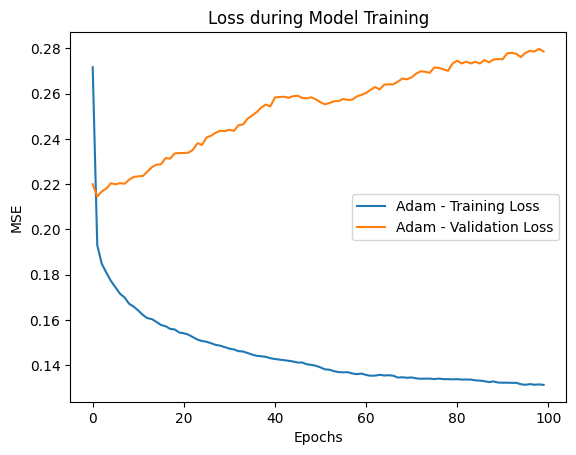

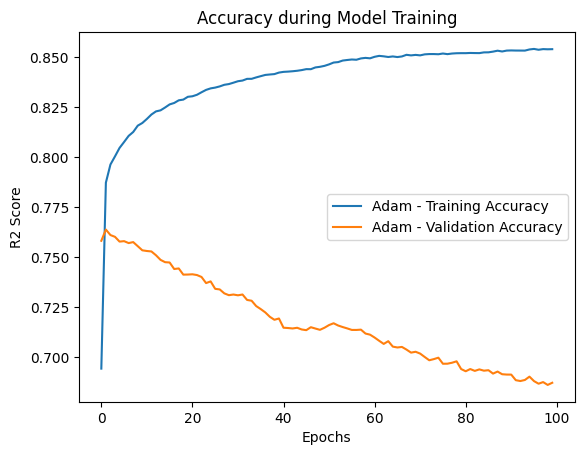

In [19]:
# Plot the training and validation accuracy and loss
plt.plot(history_adam.history["loss"], label="Adam - Training Loss")
plt.plot(history_adam.history["val_loss"], label="Adam - Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.title("Loss during Model Training")
plt.legend()
plt.show()

plt.plot(history_adam.history["r2_score"], label="Adam - Training Accuracy")
plt.plot(history_adam.history["val_r2_score"], label="Adam - Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("R2 Score")
plt.title("Accuracy during Model Training")
plt.legend()
plt.show()

Task 2.2 – Model Improvements 
Conduct a systematic investigation to optimise the deep neural network architecture by 
completing the following tasks: 
• Evaluate the effect of network depth by developing models with 1 -  4 hidden 
layers. 
• Using the most suitable depth identified, investigate the effect of varying the 
number of neurons per hidden layers. 
• Using the best architecture so far, evaluate the effect of different activation 
functions. 
• Investigate the effect of different optimisation algorithms, including appropriate 
tuning of their associated hyperparameters. 
• Evaluate suitable regularisation and generalisation techniques to reduce 
overfitting and improve model performance. 
5 
Summarise and compare the results of all experiments in well-organised tables and 
provide a justification for the final model selection based on the experimental 
findings.

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.9471 - mae: 0.7711 - r2_score: 0.0044 - val_loss: 0.6344 - val_mae: 0.6372 - val_r2_score: 0.3110
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5125 - mae: 0.5658 - r2_score: 0.4609 - val_loss: 0.4007 - val_mae: 0.5120 - val_r2_score: 0.5611
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3371 - mae: 0.4587 - r2_score: 0.6424 - val_loss: 0.3020 - val_mae: 0.4444 - val_r2_score: 0.6663
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2622 - mae: 0.4063 - r2_score: 0.7190 - val_loss: 0.2568 - val_mae: 0.4075 - val_r2_score: 0.7139
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2278 - mae: 0.3792 - r2_score: 0.7537 - val_loss: 0.2351 - val_mae: 0.3884 - val_r2_score: 0.7365
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2111 - mae: 0.3652 - r2_score: 0.7704 - val_loss: 0.2241 - val_mae: 0.3784 - val_r2_score: 0.7477
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/

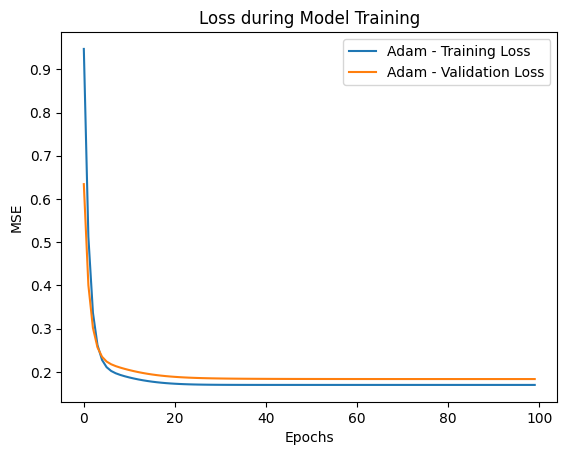

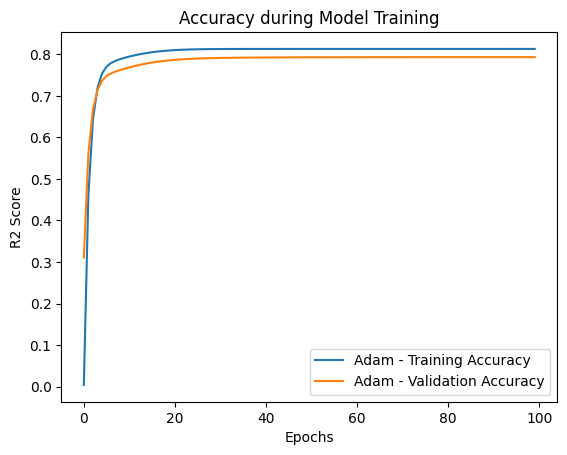

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6322 - mae: 0.6228 - r2_score: 0.3363 - val_loss: 0.3011 - val_mae: 0.4434 - val_r2_score: 0.6670
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2239 - mae: 0.3770 - r2_score: 0.7544 - val_loss: 0.2174 - val_mae: 0.3725 - val_r2_score: 0.7551
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1935 - mae: 0.3498 - r2_score: 0.7873 - val_loss: 0.2062 - val_mae: 0.3629 - val_r2_score: 0.7678
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1827 - mae: 0.3394 - r2_score: 0.7991 - val_loss: 0.1987 - val_mae: 0.3564 - val_r2_score: 0.7765
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1755 - mae: 0.3321 - r2_score: 0.8070 - val_loss: 0.1941 - val_mae: 0.3526 - val_r2_score: 0.7819
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1706 - mae: 0.3269 - r2_score: 0.8122 - val_loss: 0.1915 - val_mae: 0.3509 - val_r2_score: 0.7849
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/

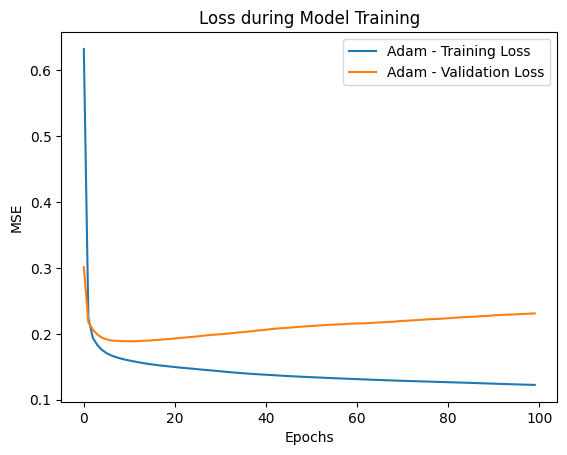

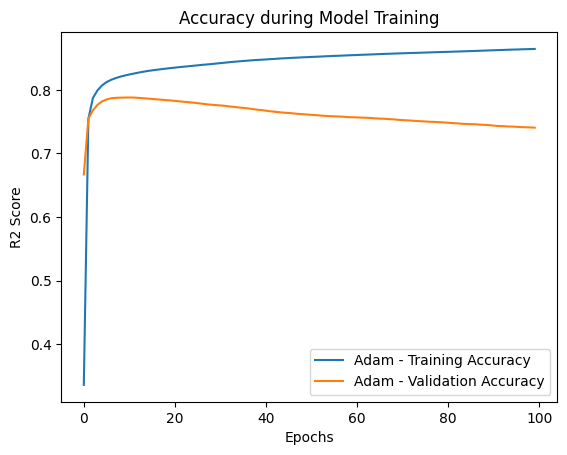

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.6611 - mae: 0.6338 - r2_score: 0.3063 - val_loss: 0.2518 - val_mae: 0.4002 - val_r2_score: 0.7209
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2126 - mae: 0.3682 - r2_score: 0.7669 - val_loss: 0.2100 - val_mae: 0.3672 - val_r2_score: 0.7647
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1885 - mae: 0.3453 - r2_score: 0.7933 - val_loss: 0.1993 - val_mae: 0.3582 - val_r2_score: 0.7768
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1783 - mae: 0.3354 - r2_score: 0.8043 - val_loss: 0.1947 - val_mae: 0.3545 - val_r2_score: 0.7821
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1725 - mae: 0.3295 - r2_score: 0.8104 - val_loss: 0.1925 - val_mae: 0.3525 - val_r2_score: 0.7846
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1688 - mae: 0.3257 - r2_score: 0.8144 - val_loss: 0.1918 - val_mae: 0.3517 - val_r2_score: 0.7855
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/

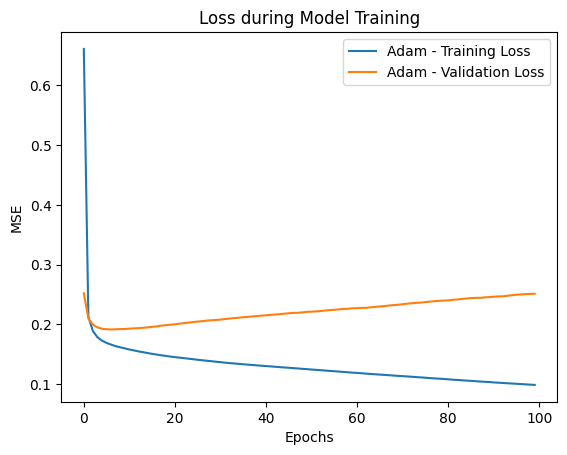

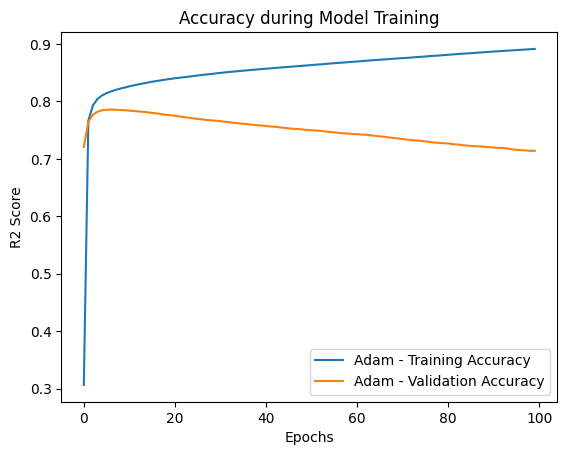

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.7688 - mae: 0.6836 - r2_score: 0.2002 - val_loss: 0.2740 - val_mae: 0.4149 - val_r2_score: 0.6923
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2203 - mae: 0.3736 - r2_score: 0.7590 - val_loss: 0.2116 - val_mae: 0.3669 - val_r2_score: 0.7616
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1909 - mae: 0.3472 - r2_score: 0.7910 - val_loss: 0.2005 - val_mae: 0.3576 - val_r2_score: 0.7741
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1802 - mae: 0.3368 - r2_score: 0.8026 - val_loss: 0.1960 - val_mae: 0.3542 - val_r2_score: 0.7794
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1743 - mae: 0.3312 - r2_score: 0.8090 - val_loss: 0.1943 - val_mae: 0.3530 - val_r2_score: 0.7816
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1704 - mae: 0.3275 - r2_score: 0.8132 - val_loss: 0.1941 - val_mae: 0.3529 - val_r2_score: 0.7819
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/

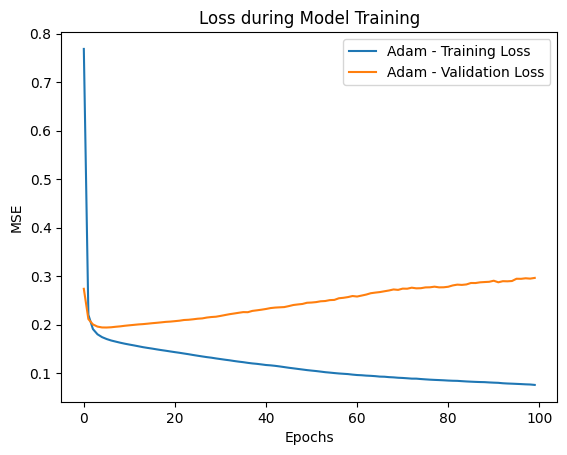

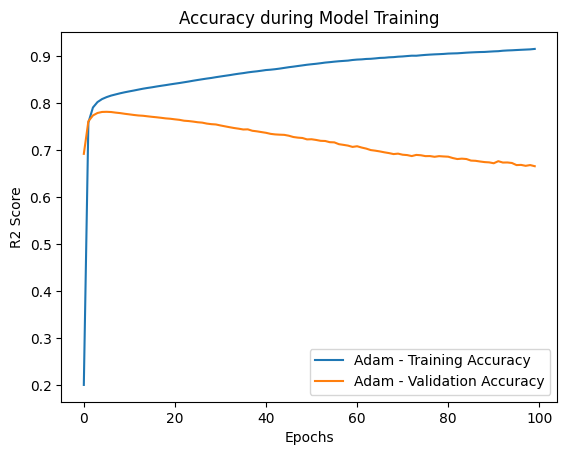

In [20]:

histories = {}
n_layers = [1,2,3,4]

optimizer = Adam(learning_rate=0.01)



for no_of_layers in n_layers:
# Create a sequential model with input layer which takes the values of 12 input parameters as input, one hidden layer with one neuron, and output layer which uses linear activation function to calculate output
    
    model = Sequential([
    Input(shape=(35,))])

    for i in range(1,no_of_layers):
        model.add(Dense(32, activation='relu', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42))) # Hidden layer with 5 neurons

    model.add(Dense(1, activation='linear', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42)))
    



    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae',R2_score]
)

    # Train the model using GD with train dataset and validate the model using validation dataset during training
    start_time = time.time()

    history_adam_1 = model.fit(
        X_train_scaled,
        y_train_scaled,
        epochs=100,
        batch_size=32, # batch_size > training_dataset_size --> use GD
        validation_data=(X_val_scaled, y_val_scaled),
        verbose=1
    )

    end_time = time.time()
    training_time = end_time - start_time

 


    
    histories[no_of_layers] = history_adam_1

    # make Predictions using the Model
    y_true = y_test
    y_pred = np.argmax(model.predict(X_test_scaled), axis=1) # convert probabilities to class labels

    y_prob = model.predict(X_test_scaled)
    
    print('-----------------------------------------------------------------------------------------------------------------------')
    print('The results with %f no. of layers', no_of_layers)
    print('-----------------------------------------------------------------------------------------------------------------------')

   
   
   # Plot the training and validation accuracy and loss
    plt.plot(history_adam_1.history["loss"], label="Adam - Training Loss")
    plt.plot(history_adam_1.history["val_loss"], label="Adam - Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("MSE")
    plt.title("Loss during Model Training")
    plt.legend()
    plt.show()

    plt.plot(history_adam_1.history["r2_score"], label="Adam - Training Accuracy")
    plt.plot(history_adam_1.history["val_r2_score"], label="Adam - Validation Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("R2 Score")
    plt.title("Accuracy during Model Training")
    plt.legend()
    plt.show()



The results of the tuning of the number of layers from 1 to 4 shows that 4 layers slightly decresed the errors. So we can use 4 layer.  

In [21]:
histories = {}
n_layers = [1,2,3,4]

opt = Adam(learning_rate=0.01)



for no_of_layers in n_layers:
# Create a sequential model with input layer which takes the values of 12 input parameters as input, one hidden layer with one neuron, and output layer which uses linear activation function to calculate output
    
    model = Sequential([
    Input(shape=(35,))])

    for i in range(1,no_of_layers):
        model.add(Dense(32, activation='relu', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42))) # Hidden layer with 5 neurons

    model.add(Dense(1, activation='linear', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42)))
    



    model.compile(
        optimizer=opt,
        loss='mse',
        metrics=['mae',R2_score]
)

    # Train the model using GD with train dataset and validate the model using validation dataset during training
    start_time = time.time()

    history_adam = model.fit(
        X_train_scaled,
        y_train_scaled,
        epochs=100,
        batch_size=32, # batch_size > training_dataset_size --> use GD
        validation_data=(X_val_scaled, y_val_scaled),
        verbose=1
    )

    end_time = time.time()
    training_time = end_time - start_time

 


    
    histories[no_of_layers] = history

    # make Predictions using the Model
    y_true = y_test
    y_pred = np.argmax(model.predict(X_test_scaled), axis=1) # convert probabilities to class labels

    y_prob = model.predict(X_test_scaled)
    
    print('-----------------------------------------------------------------------------------------------------------------------')
    print('The results with %f no. of layers', no_of_layers)
    print('-----------------------------------------------------------------------------------------------------------------------')

   
   
   # Plot the training and validation accuracy and loss
    plt.plot(history_adam.history["loss"], label="Adam - Training Loss")
    plt.plot(history_adam.history["val_loss"], label="Adam - Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("MSE")
    plt.title("Loss during Model Training")
    plt.legend()
    plt.show()

    plt.plot(history_adam.history["r2_score"], label="Adam - Training Accuracy")
    plt.plot(history_adam.history["val_r2_score"], label="Adam - Validation Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("R2 Score")
    plt.title("Accuracy during Model Training")
    plt.legend()
    plt.show()









# This method creates the model with different hyperparameters
def create_model(n_layers=1, n_neurons=32, activation='relu', learning_rate=0.001):
    
    model = Sequential()
   
    # Input + first hidden layer
    model.add(tf.keras.layers.Input(shape=(12,)))
    model_adam.add(Dense(32, activation='relu', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42))) # Hidden layer with 5 neurons
    # Additional hidden layers
    for _ in range(n_layers - 1):
        model.add(tf.keras.layers.Dense(n_neurons, activation=activation))
    
    # Output layer (for classification with 3 classes)
    model.add(tf.keras.layers.Dense(3, activation='sigmoid'))
    
    # Optimizer with learning rate
    optimizer = Adam(learning_rate=learning_rate)
    
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

model = KerasClassifier(model=create_model, verbose=0)

# define the parameter grid
# Gives total combinations = 3 × 3 × 2 × 2 × 2 × 2 = 144 models
param_grid = {
    "model__n_layers": [1, 2, 3],
    "model__n_neurons": [16, 32, 64],
    "model__activation": ["relu", "tanh"],
    "model__learning_rate": [0.001, 0.01],
    "batch_size": [8, 16],
    "epochs": [50, 100]
}

grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_result = grid.fit(X_train, y_train)

print("Best Parameters:", grid_result.best_params_)
print("Best CV Score:", grid_result.best_score_)

best_model = grid_result.best_estimator_

test_accuracy = best_model.score(X_test, y_test)
print("Test Accuracy:", test_accuracy)

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3199 - mae: 0.4351 - r2_score: 0.6411 - val_loss: 0.2117 - val_mae: 0.3663 - val_r2_score: 0.7610
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1895 - mae: 0.3456 - r2_score: 0.7918 - val_loss: 0.1977 - val_mae: 0.3538 - val_r2_score: 0.7778
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1831 - mae: 0.3384 - r2_score: 0.7987 - val_loss: 0.1943 - val_mae: 0.3505 - val_r2_score: 0.7820
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1823 - mae: 0.3373 - r2_score: 0.7994 - val_loss: 0.1938 - val_mae: 0.3496 - val_r2_score: 0.7829
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1825 - mae: 0.3373 - r2_score: 0.7992 - val_loss: 0.1938 - val_mae: 0.3494 - val_r2_score: 0.7831
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1827 - mae: 0.3376 - r2_score: 0.7989 - val_loss: 0.1939 - val_mae: 0.3494 - val_r2_score: 0.7830
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/

NameError: name 'history' is not defined

In [ ]:


# Compute the coefficient of determination (R² score), a metric for regression models.
def R2_score(y_true, y_pred):
    y_true = K.cast(y_true, dtype='float32')  # fix the type mismatch
    ss_res = K.sum(K.square(y_true - y_pred))
    ss_tot = K.sum(K.square(y_true - K.mean(y_true)))
    return 1 - ss_res / (ss_tot + K.epsilon())


# Create a sequential model with input layer which takes the values of 12 input parameters as input, one hidden layer with one neuron, and output layer which uses linear activation function to calculate output
model_adam = Sequential([
    Input(shape=(35,)),
    Dense(32, activation='relu', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42)), # Hidden layer with 5 neurons
    Dense(1, activation='linear', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42))
    ])

opt = Adam(learning_rate=0.01)

model_adam.compile(
    optimizer=opt,
    loss='mse',
    metrics=['mae',R2_score]
)

# Train the model using GD with train dataset and validate the model using validation dataset during training
start_time = time.time()

history_adam = model_adam.fit(
    X_train_scaled,
    y_train_scaled,
    epochs=100,
    batch_size=32, # batch_size > training_dataset_size --> use GD
    validation_data=(X_val_scaled, y_val_scaled),
    verbose=1
)

end_time = time.time()
training_time = end_time - start_time

print(f"Training time: {training_time:.2f} seconds")
print(f"Training time: {training_time/60:.2f} minutes")

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2717 - mae: 0.4106 - r2_score: 0.6942 - val_loss: 0.2199 - val_mae: 0.3746 - val_r2_score: 0.7582
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1930 - mae: 0.3491 - r2_score: 0.7873 - val_loss: 0.2145 - val_mae: 0.3707 - val_r2_score: 0.7638
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1847 - mae: 0.3400 - r2_score: 0.7963 - val_loss: 0.2168 - val_mae: 0.3727 - val_r2_score: 0.7611
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1808 - mae: 0.3358 - r2_score: 0.8004 - val_loss: 0.2180 - val_mae: 0.3738 - val_r2_score: 0.7602
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1772 - mae: 0.3317 - r2_score: 0.8046 - val_loss: 0.2204 - val_mae: 0.3763 - val_r2_score: 0.7578
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1743 - mae: 0.3289 - r2_score: 0.8076 - val_loss: 0.2199 - val_mae: 0.3759 - val_r2_score: 0.7580
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/

In [ ]:
df["Fertility_Class"] = pd.qcut(
    df["Fertility_Score"],
    q=3,
    labels=["Low", "Medium", "High"]
)  

X = df.drop(["Sample_ID", "Fertility_Score", "Fertility_Class"], axis=1)
y = df["Fertility_Class"]

# Encoding classes
le = LabelEncoder()
y = le.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.5, random_state=42)

# Scaling data
scaler_X = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled  = scaler_X.transform(X_test)
X_val_scaled  = scaler_X.transform(X_val)

# This method creates the model with different hyperparameters
def create_model(n_layers=1, n_neurons=32, activation='relu', learning_rate=0.001):
    
    model = tf.keras.Sequential()
    
    # Input + first hidden layer
    model.add(tf.keras.layers.Input(shape=(12,)))
    
    # Additional hidden layers
    for _ in range(n_layers - 1):
        model.add(tf.keras.layers.Dense(n_neurons, activation=activation))
    
    # Output layer (for classification with 3 classes)
    model.add(tf.keras.layers.Dense(3, activation='sigmoid'))
    
    # Optimizer with learning rate
    optimizer = Adam(learning_rate=learning_rate)
    
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

model = KerasClassifier(model=create_model, verbose=0)

# define the parameter grid
# Gives total combinations = 3 × 3 × 2 × 2 × 2 × 2 = 144 models
param_grid = {
    "model__n_layers": [1, 2, 3],
    "model__n_neurons": [16, 32, 64],
    "model__activation": ["relu", "tanh"],
    "model__learning_rate": [0.001, 0.01],
    "batch_size": [8, 16],
    "epochs": [50, 100]
}

grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_result = grid.fit(X_train, y_train)

print("Best Parameters:", grid_result.best_params_)
print("Best CV Score:", grid_result.best_score_)

best_model = grid_result.best_estimator_

test_accuracy = best_model.score(X_test, y_test)
print("Test Accuracy:", test_accuracy)